# Object Detection


In [1]:
!pip install mean_average_precision

In [2]:
import os
import sys
import cv2
import json
import matplotlib.pyplot as plt

import numpy as np
import torch
from torch import nn
from torchvision.transforms.functional import to_tensor, normalize
from torchvision.ops import nms
import seaborn as sns

import torch.utils.data
from PIL import Image

from mean_average_precision import MetricBuilder
import gc
import tqdm

from torchvision import transforms
from torch.utils.data import DataLoader
import warnings

import skimage

warnings.filterwarnings("ignore")


# %reload_ext autoreload

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device is:", device)

Device is: cuda


In [3]:
!gdown "1vEA1yc7eri3YpXE9YqCCqxwJh3_UeKjR"

Downloading...
From (original): https://drive.google.com/uc?id=1vEA1yc7eri3YpXE9YqCCqxwJh3_UeKjR
From (redirected): https://drive.google.com/uc?id=1vEA1yc7eri3YpXE9YqCCqxwJh3_UeKjR&confirm=t&uuid=f48085e0-39dd-4a35-90a3-159c60df3499
To: /content/dl-6-content.zip
100% 1.08G/1.08G [00:28<00:00, 38.4MB/s]


In [4]:
!unzip dl-6-content.zip

Streaming output truncated to the last 5000 lines.
  inflating: dl-6-content/oi5_ball/1140.jpg  
  inflating: __MACOSX/dl-6-content/oi5_ball/._1140.jpg  
  inflating: dl-6-content/oi5_ball/2461.jpg  
  inflating: __MACOSX/dl-6-content/oi5_ball/._2461.jpg  
  inflating: dl-6-content/oi5_ball/0276.jpg  
  inflating: __MACOSX/dl-6-content/oi5_ball/._0276.jpg  
  inflating: dl-6-content/oi5_ball/1168.jpg  
  inflating: __MACOSX/dl-6-content/oi5_ball/._1168.jpg  
  inflating: dl-6-content/oi5_ball/0510.jpg  
  inflating: __MACOSX/dl-6-content/oi5_ball/._0510.jpg  
  inflating: dl-6-content/oi5_ball/3019.jpg  
  inflating: __MACOSX/dl-6-content/oi5_ball/._3019.jpg  
  inflating: dl-6-content/oi5_ball/2307.jpg  
  inflating: __MACOSX/dl-6-content/oi5_ball/._2307.jpg  
  inflating: dl-6-content/oi5_ball/2313.jpg  
  inflating: __MACOSX/dl-6-content/oi5_ball/._2313.jpg  
  inflating: dl-6-content/oi5_ball/0504.jpg  
  inflating: __MACOSX/dl-6-content/oi5_ball/._0504.jpg  
  inflating: dl-6-cont



## RetinaNet-style detector

RetinaNet используется как основной one-stage object detector. Ниже реализуются ключевые компоненты архитектуры и проверяется их работа на изображениях.

## Данные и визуализация

In [15]:
def show_image(image, figsize=(10, 10)):
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis("off")
    plt.show()


def draw_predictions(image, bboxes, scores, classes, class_to_label_map=None, threshold=0.5):
    palette = sns.color_palette(None, len(class_to_label_map))
    image_with_predictions = image.copy()

    for bbox, score, class_int in zip(bboxes, scores, classes):
        if score < threshold:
            continue

        x1, y1, x2, y2 = bbox.numpy().astype(np.int32)
        label = class_to_label_map[class_int.item()]
        color = palette[class_int.item()]

        cv2.rectangle(image_with_predictions, (x1, y1), (x2, y2), np.array(color) * 255, 2)
        if class_to_label_map is not None:
            cv2.putText(image_with_predictions, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, np.array(color) * 255, 2)


    return image_with_predictions

In [16]:
def make_tensor(image, device=None):
    tensor = to_tensor(image).unsqueeze(0)
    tensor = normalize(tensor,
                       mean=(0.485, 0.456, 0.406),
                       std=(0.229, 0.224, 0.225))
    if device:
        tensor = tensor.to(device)
    return tensor

Image shape (540, 800, 3)
Tensor size torch.Size([1, 3, 540, 800])


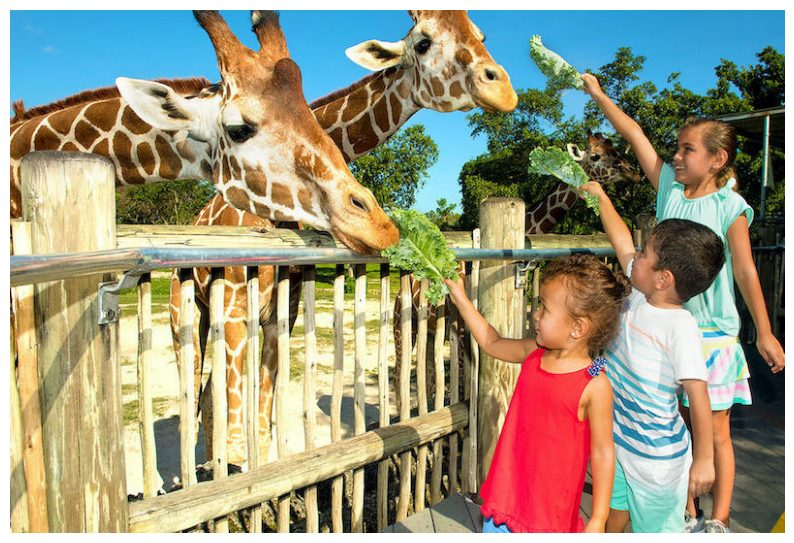

In [17]:
image_example = cv2.imread("/content/dl-6-content/images/zoo.jpg")


image_example = cv2.cvtColor(image_example, cv2.COLOR_BGR2RGB)
print("Image shape", image_example.shape)

tensor_example = make_tensor(image_example, device)
print("Tensor size", tensor_example.size())

show_image(image_example)

## Реализация компонентов RetinaNet

Модель собирается из нескольких модулей:

- `backbone` — извлечение признаков из изображения;
- `fpn` — построение feature pyramid;
- `anchor_generator` — генерация anchor boxes;
- `cls_head` — предсказание класса объекта;
- `reg_head` — уточнение координат bounding boxes.

#### Backbone: Модифицированный ResNet

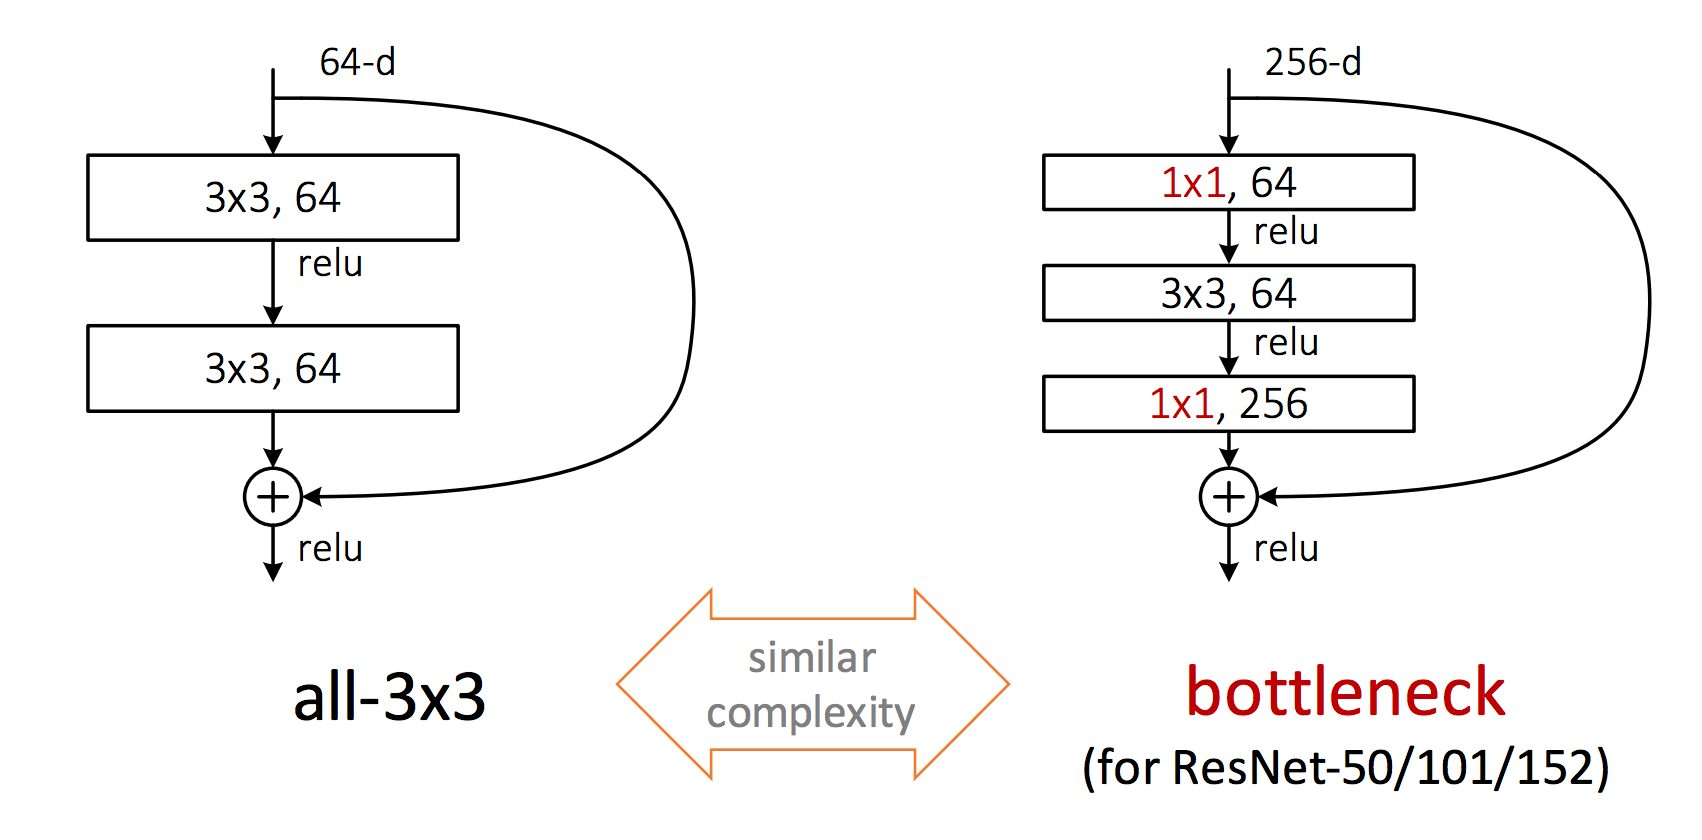

In [18]:
def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, planes * 4, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * 4)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out

In [19]:
class ResNet(nn.Module):

    def __init__(self, num_classes, block, layers_sizes):
        """
        ResNet constructor.

        Args:
            - num_classes: int number of outputs for model.
            - block: class to use as residual block in model (BasicBlock or Bottleneck).
            - layers_sizes: list of sizes (number of blocks) for each of the 4 layers.
        """
        self.inplanes = 64
        super(ResNet, self).__init__()

        # Input convolution: larger (7x7) and with increased stride (2).
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Four layers with residual blocks. Each layer has similar structure
        self.layer1 = self._make_layer(block, 64, layers_sizes[0])
        self.layer2 = self._make_layer(block, 128, layers_sizes[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers_sizes[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers_sizes[3], stride=2)

    def _make_layer(self, block, planes, num_blocks, stride=1):
        """
        Method to create layer for ResNet using residual blocks.

        Args:
            - block: class to use as residual block in model (BasicBlock or Bottleneck).
            - planes: number of channels in layer's activation maps (also known as layer 'width').
            - num_blocks: number of blocks in layer.

        Returns:
            nn.Sequential object containing residual blocks.
        """
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for i in range(1, num_blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, inputs):
        """
        Method for "__call__".

        Args:
            - inputs: batch of images shaped Bx3xHxW.

        Returns:
            List of feature maps tensors from layers 2, 3, 4.
        """

        # TODO:
        # Write code to run all the model layers (do not forget to run input convolution/bn/activation/pooling)
        # and to return feature maps from layer2, layer3, layer4.

        ### YOUR CODE HERE

        #прогоняем вход через stem-блок ResNet (conv -> bn -> relu -> maxpool)
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        #последовательно проходим residual слои и сохраняем карты C3, C4, C5
        x = self.layer1(x)
        x2 = self.layer2(x)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        ### END OF YOUR CODE

        return (x2, x3, x4)

In [20]:
num_classes = 80

print("ResNet50:")
resnet50_layers_sizes = [3, 4, 6, 3]
resnet50 = ResNet(num_classes=num_classes, block=Bottleneck, layers_sizes=resnet50_layers_sizes).to(device)

print(resnet50)

ResNet50:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), s

In [21]:
print("Feature maps sizes from layer2-4 of ResNet50:")
feature_maps_example = resnet50(tensor_example)
for fm in feature_maps_example:
    print(fm.size())

Feature maps sizes from layer2-4 of ResNet50:
torch.Size([1, 512, 68, 100])
torch.Size([1, 1024, 34, 50])
torch.Size([1, 2048, 17, 25])


#### Feature Pyramid: собираем пирамиду активаций


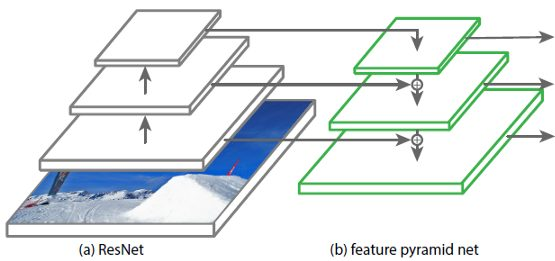

In [22]:
class PyramidFeatures(nn.Module):

    def __init__(self, C3_size, C4_size, C5_size, feature_size=256):
        """
        FPN constructor.

        Args:
            - C3_size: num features in C3 map.
            - C4_size: num features in C4 map.
            - C5_size: num features in C5 map.
            - feature_size: num features in output maps.
        """
        super(PyramidFeatures, self).__init__()

        # For P5
        self.P5_1 = nn.Conv2d(C5_size, feature_size, kernel_size=1, stride=1, padding=0)
        self.P5_upsampled = nn.Upsample(scale_factor=2, mode='nearest')
        self.P5_2 = nn.Conv2d(feature_size, feature_size, kernel_size=3, stride=1, padding=1)

        # For P4
        self.P4_1 = nn.Conv2d(C4_size, feature_size, kernel_size=1, stride=1, padding=0)
        self.P4_upsampled = nn.Upsample(scale_factor=2, mode='nearest')
        self.P4_2 = nn.Conv2d(feature_size, feature_size, kernel_size=3, stride=1, padding=1)

        # For P3
        self.P3_1 = nn.Conv2d(C3_size, feature_size, kernel_size=1, stride=1, padding=0)
        self.P3_2 = nn.Conv2d(feature_size, feature_size, kernel_size=3, stride=1, padding=1)

        # For P6
        # "P6 is obtained via a 3x3 stride-2 conv on C5"
        self.P6 = nn.Conv2d(C5_size, feature_size, kernel_size=3, stride=2, padding=1)

        # For P7
        # "P7 is computed by applying ReLU followed by a 3x3 stride-2 conv on P6"
        self.P7_1 = nn.ReLU()
        self.P7_2 = nn.Conv2d(feature_size, feature_size, kernel_size=3, stride=2, padding=1)

    def forward(self, inputs):
        """
        Method for "__call__".

        Args:
            - inputs: List of C3, C4, C5 activation maps from backbone.

        Returns:
            List of pyramid feature maps from P3 to P7.
        """
        C3, C4, C5 = inputs

        P5_x = self.P5_1(C5)
        P5_upsampled_x = self.P5_upsampled(P5_x)
        P5_x = self.P5_2(P5_x)

        P4_x = self.P4_1(C4)
        P4_x = P5_upsampled_x + P4_x
        P4_upsampled_x = self.P4_upsampled(P4_x)
        P4_x = self.P4_2(P4_x)

        # TODO:
        # Write code to compute P3_x output map.
        # Almost like P4_x & P5_x, but no need for upsampling itself
        # (as we do not have 'lower' map P2)

        # YOUR CODE HERE

        # Для P3 делаем lateral 1x1 conv на C3, добавляем upsampled P4 и сглаживаем 3x3 conv
        P3_x = self.P3_1(C3)
        P3_x = P3_x + P4_upsampled_x
        P3_x = self.P3_2(P3_x)

        # END OF YOUR CODE

        P6_x = self.P6(C5)

        P7_x = self.P7_1(P6_x)
        P7_x = self.P7_2(P7_x)

        return (P3_x, P4_x, P5_x, P6_x, P7_x)

In [23]:
fpn_sizes = (512, 1024, 2048)  # ResNet50
fpn = PyramidFeatures(*fpn_sizes).to(device)

print("Feature pyramid sizes:")
features_pyramid_example = fpn(feature_maps_example)
for fp in features_pyramid_example:
    print(fp.size())

Feature pyramid sizes:
torch.Size([1, 256, 68, 100])
torch.Size([1, 256, 34, 50])
torch.Size([1, 256, 17, 25])
torch.Size([1, 256, 9, 13])
torch.Size([1, 256, 5, 7])


В отличие от two-stage detectors, RetinaNet предсказывает классы и координаты объектов напрямую по dense anchors на feature maps.

### Anchors Generator

In [24]:
def generate_anchors(base_size=16, ratios=None, scales=None):
    """
    Generate anchor (reference) windows by enumerating aspect ratios X
    scales w.r.t. a reference window.
    """

    if ratios is None:
        ratios = np.array([0.5, 1, 2])

    if scales is None:
        scales = np.array([2 ** 0, 2 ** (1.0 / 3.0), 2 ** (2.0 / 3.0)])

    num_anchors = len(ratios) * len(scales)

    # initialize output anchors
    anchors = np.zeros((num_anchors, 4))

    # scale base_size
    anchors[:, 2:] = base_size * np.tile(scales, (2, len(ratios))).T

    # compute areas of anchors
    areas = anchors[:, 2] * anchors[:, 3]

    # correct for ratios
    anchors[:, 2] = np.sqrt(areas / np.repeat(ratios, len(scales)))
    anchors[:, 3] = anchors[:, 2] * np.repeat(ratios, len(scales))

    # transform from (x_ctr, y_ctr, w, h) -> (x1, y1, x2, y2)
    anchors[:, 0::2] -= np.tile(anchors[:, 2] * 0.5, (2, 1)).T
    anchors[:, 1::2] -= np.tile(anchors[:, 3] * 0.5, (2, 1)).T

    return anchors


def shift(shape, stride, anchors):
    shift_x = (np.arange(0, shape[1]) + 0.5) * stride
    shift_y = (np.arange(0, shape[0]) + 0.5) * stride

    shift_x, shift_y = np.meshgrid(shift_x, shift_y)

    shifts = np.vstack((
        shift_x.ravel(), shift_y.ravel(),
        shift_x.ravel(), shift_y.ravel()
    )).transpose()

    # add A anchors (1, A, 4) to
    # cell K shifts (K, 1, 4) to get
    # shift anchors (K, A, 4)
    # reshape to (K*A, 4) shifted anchors
    A = anchors.shape[0]
    K = shifts.shape[0]
    all_anchors = (anchors.reshape((1, A, 4)) + shifts.reshape((1, K, 4)).transpose((1, 0, 2)))
    all_anchors = all_anchors.reshape((K * A, 4))

    return all_anchors

In [25]:
class AnchorsGenerator(nn.Module):

    def __init__(self, pyramid_levels=None, strides=None, sizes=None, ratios=None, scales=None, device=None):
        """
        AnchorGenerator constructor.

        Args:
            - pyramid_levels: list of log_2(image_width / pyramid_level_width) for every pyramid level.
            - strides: list of step sizes for sliding each anchor box set for every pyramid level.
            - sizes: list of basic sizes for anchor boxes for every pyramid level.
            - ratios: list of anchor boxes aspect ratio sets for every pyramid level.
            - scales: list of anchor boxes scale sets for every pyramid level.
            - device: device to move results to.
        """
        super(AnchorsGenerator, self).__init__()

        if pyramid_levels is None:
            self.pyramid_levels = [3, 4, 5, 6, 7]
        if strides is None:
            self.strides = [2 ** x for x in self.pyramid_levels]
        if sizes is None:
            self.sizes = [2 ** (x + 2) for x in self.pyramid_levels]
        if ratios is None:
            self.ratios = np.array([0.5, 1, 2])
        if scales is None:
            self.scales = np.array([2 ** 0, 2 ** (1.0 / 3.0), 2 ** (2.0 / 3.0)])

        if device is None:
            device = torch.cuda.is_available() and 'cuda' or 'cpu'
        self.device = device

    def forward(self, image, verbose=False):
        """
        Method for "__call__".

        Args:
            - image: tensor of shape B x C x H x W.

        Returns:
            tensor of computed anchor box coordinatates, size total_num_anchors x 4.
        """
        image_shape = image.shape[2:]  # h, w
        image_shape = np.array(image_shape)
        image_shapes = [(image_shape + 2 ** x - 1) // (2 ** x) for x in self.pyramid_levels]

        # Compute anchors over all pyramid levels

        all_anchors = np.zeros((0, 4)).astype(np.float32)

        for idx, p in enumerate(self.pyramid_levels):

            # Generate 9 anchors
            anchors = generate_anchors(base_size=self.sizes[idx], ratios=self.ratios, scales=self.scales)

            # Grid all over the shape with stride
            shifted_anchors = shift(image_shapes[idx], self.strides[idx], anchors)

            if verbose:
                print(f"{idx}\tpyr_level = {p}\tstride = {self.strides[idx]:3d}\tsize={self.sizes[idx]:3d}\tanchors shape = {shifted_anchors.shape}")

            all_anchors = np.append(all_anchors, shifted_anchors, axis=0)

        all_anchors = np.expand_dims(all_anchors, axis=0)

        return torch.from_numpy(all_anchors.astype(np.float32)).to(self.device)

In [26]:
anchors_generator = AnchorsGenerator(device=device)

anchors_example = anchors_generator(tensor_example, verbose=True)[0].cpu()
print()
print(anchors_example.size())

0	pyr_level = 3	stride =   8	size= 32	anchors shape = (61200, 4)
1	pyr_level = 4	stride =  16	size= 64	anchors shape = (15300, 4)
2	pyr_level = 5	stride =  32	size=128	anchors shape = (3825, 4)
3	pyr_level = 6	stride =  64	size=256	anchors shape = (1053, 4)
4	pyr_level = 7	stride = 128	size=512	anchors shape = (315, 4)

torch.Size([81693, 4])


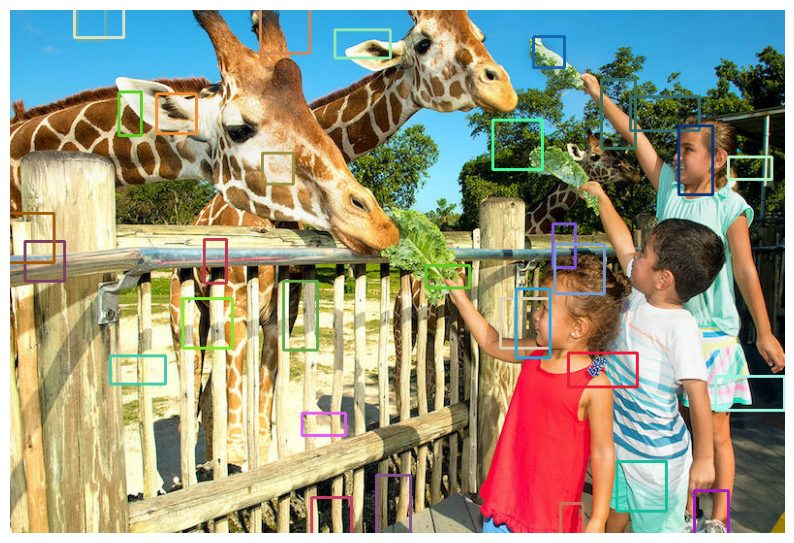

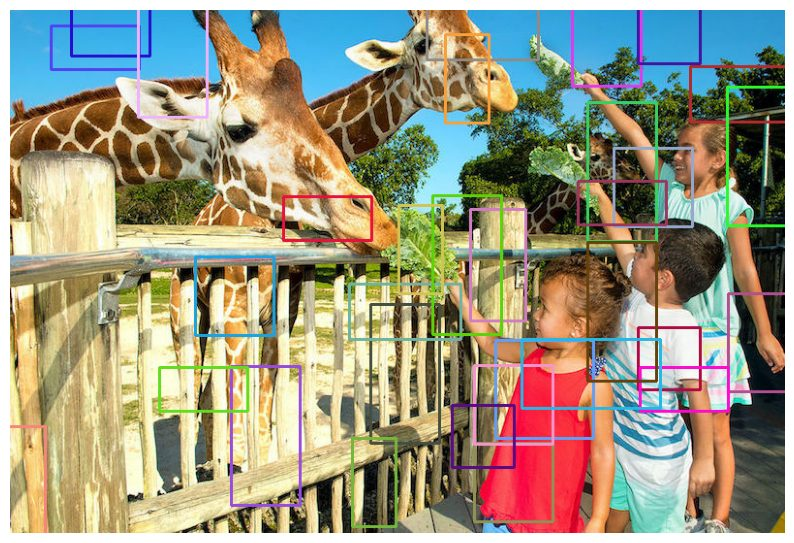

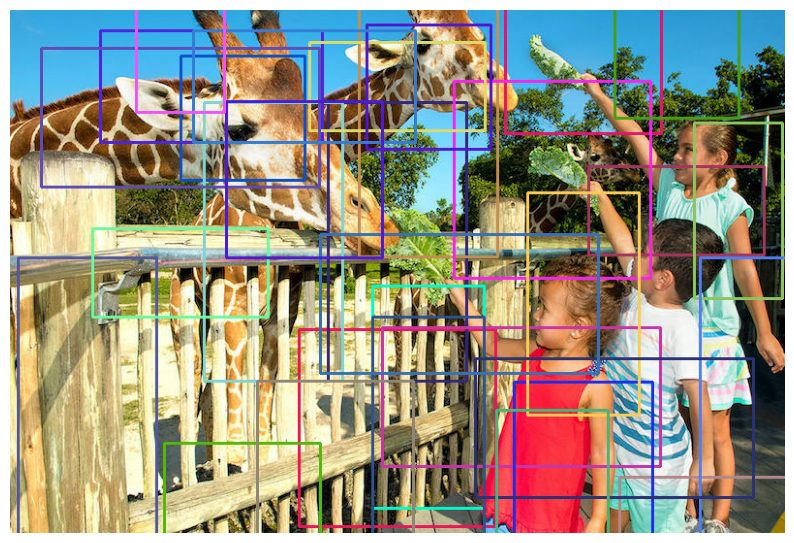

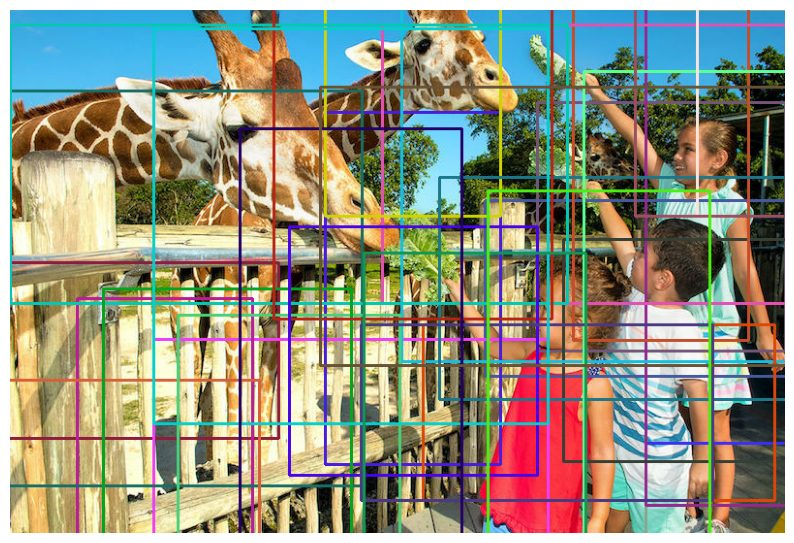

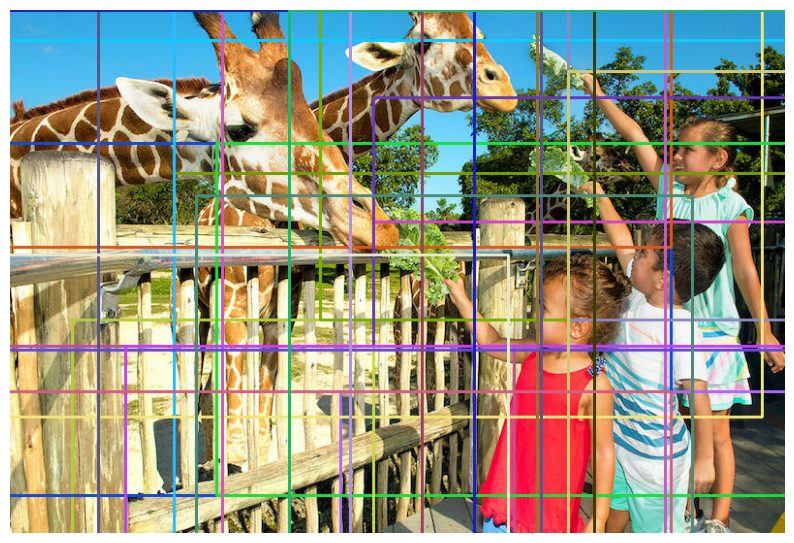

In [27]:
anchors_num_per_level = [61200, 15300, 3825, 1053, 315]
anchors_per_level = np.split(anchors_example, np.cumsum(anchors_num_per_level)[:-1])

num_to_show = 32
for anchor_boxes_level in anchors_per_level:
    image_example_with_anchors = image_example.copy()
    for i in np.random.choice(len(anchor_boxes_level), size=num_to_show):
        anchor_box = anchor_boxes_level[i]
        x1, y1, x2, y2 = anchor_box.numpy().astype(np.int32)
        cv2.rectangle(image_example_with_anchors, (x1, y1), (x2, y2), np.random.randint(255, size=3).tolist(), 2)

    show_image(image_example_with_anchors)

### Classification and regression heads

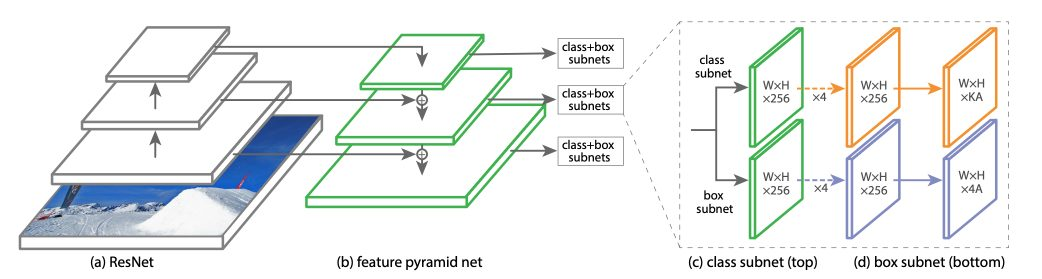

In [28]:
class RegressionModel(nn.Module):

    def __init__(self, num_features_in, num_anchors=9, feature_size=256):
        """
        RegressionModel consctructor.

        RegressionModel is a fully-convolutional neural network that takes single feature pyramid level and
        outputs tensor of size total_number_of_anchors x 4.

        Args:
            - num_features_in: number of channels in every feature pyramid level.
            - num_anchors: size of anchor boxes set.
            - feature_size: size of internal activation maps.
        """
        super(RegressionModel, self).__init__()

        self.conv1 = nn.Conv2d(num_features_in, feature_size, kernel_size=3, padding=1)
        self.act1 = nn.ReLU()

        self.conv2 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.act2 = nn.ReLU()

        self.conv3 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.act3 = nn.ReLU()

        self.conv4 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.act4 = nn.ReLU()

        self.output = nn.Conv2d(feature_size, num_anchors * 4, kernel_size=3, padding=1)

    def forward(self, x):
        """
        Run regression on single feature pyramid level.

        Args:
            - x: feature pyramid level of shape B x num_features_in x H x W.

        Returns:
            tensor of size B x (H * W * num_anchors) x 4.
        """
        out = self.conv1(x)
        out = self.act1(out)

        out = self.conv2(out)
        out = self.act2(out)

        out = self.conv3(out)
        out = self.act3(out)

        out = self.conv4(out)
        out = self.act4(out)

        out = self.output(out)
        # out is B x C x H x W, with C = 4 * num_anchors

        # Переставляем оси: каналы (4 * num_anchors) переносим в конец, чтобы удобно сгруппировать координаты.
        out = out.permute(0, 2, 3, 1)

        # Преобразуем в B x total_num_anchors x 4, где каждые 4 числа — (dx, dy, dw, dh) для одного anchor.
        out = out.reshape(x.shape[0], -1, 4)

        return out

In [29]:
num_features_in = 256
regression_head = RegressionModel(num_features_in).to(device)

regression_predictions = []
for features in features_pyramid_example:
    regression_predictions_at_level = regression_head(features)
    regression_predictions.append(regression_predictions_at_level)
    print(f"input: {features.size()}\t output: {regression_predictions_at_level.size()}")
regression_predictions = torch.cat(regression_predictions, dim=1) # batch x anchors x 4 [4 for bbox]

input: torch.Size([1, 256, 68, 100])	 output: torch.Size([1, 61200, 4])
input: torch.Size([1, 256, 34, 50])	 output: torch.Size([1, 15300, 4])
input: torch.Size([1, 256, 17, 25])	 output: torch.Size([1, 3825, 4])
input: torch.Size([1, 256, 9, 13])	 output: torch.Size([1, 1053, 4])
input: torch.Size([1, 256, 5, 7])	 output: torch.Size([1, 315, 4])


**Clasification head**


In [30]:
class ClassificationModel(nn.Module):

    def __init__(self, num_features_in, num_anchors=9, num_classes=80, prior=0.01, feature_size=256):
        """
        ClassificationModel consctructor.

        ClassificationModel is a fully-convolutional neural network that takes single feature pyramid level and
        outputs tensor of size total_number_of_anchors x num_classes.

        Args:
            - num_features_in: number of channels in every feature pyramid level.
            - num_anchors: size of anchor boxes set.
            - num_classes: number of classes in dataset (do not count the `background` class!).
            - prior: float number to use in weights initializatin.
            - feature_size: size of internal activation maps.
        """
        super(ClassificationModel, self).__init__()

        self.num_classes = num_classes
        self.num_anchors = num_anchors

        self.conv1 = nn.Conv2d(num_features_in, feature_size, kernel_size=3, padding=1)
        self.act1 = nn.ReLU()

        self.conv2 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.act2 = nn.ReLU()

        self.conv3 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.act3 = nn.ReLU()

        self.conv4 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.act4 = nn.ReLU()

        self.output = nn.Conv2d(feature_size, num_anchors * num_classes, kernel_size=3, padding=1)
        self.output_act = nn.Sigmoid()

    def forward(self, x):
        """
        Run classification on single feature pyramid level.

        Args:
            - x: feature pyramid level of shape B x num_features_in x H x W.

        Returns:
            tensor of size B x (H * W * num_anchors) x num_classes.
        """
        out = self.conv1(x)
        out = self.act1(out)

        out = self.conv2(out)
        out = self.act2(out)

        out = self.conv3(out)
        out = self.act3(out)

        out = self.conv4(out)
        out = self.act4(out)

        out = self.output(out)
        out = self.output_act(out)
        # out is B x C x W x H, with C = num_classes * num_anchors

        out1 = out.permute(0, 2, 3, 1)
        batch_size, width, height, channels = out1.shape
        out2 = out1.reshape(batch_size, width, height, self.num_anchors, self.num_classes)

        return out2.reshape(x.shape[0], -1, self.num_classes)

In [31]:
classification_head = ClassificationModel(num_features_in, num_classes=num_classes).to(device)
classification_results = []

for feature in features_pyramid_example:
    classification_results_at_level = classification_head(feature)
    classification_results.append(classification_results_at_level)
    print(f"input: {feature.size()}\t output: {classification_results_at_level.size()}")
classification_results = torch.cat(classification_results, dim=1) # batch x anchors x classes

input: torch.Size([1, 256, 68, 100])	 output: torch.Size([1, 61200, 80])
input: torch.Size([1, 256, 34, 50])	 output: torch.Size([1, 15300, 80])
input: torch.Size([1, 256, 17, 25])	 output: torch.Size([1, 3825, 80])
input: torch.Size([1, 256, 9, 13])	 output: torch.Size([1, 1053, 80])
input: torch.Size([1, 256, 5, 7])	 output: torch.Size([1, 315, 80])


### Сборка RetinaNet

In [32]:
def calc_iou(a, b):
    area = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])

    iw = torch.min(torch.unsqueeze(a[:, 2], dim=1), b[:, 2]) - torch.max(torch.unsqueeze(a[:, 0], 1), b[:, 0])
    ih = torch.min(torch.unsqueeze(a[:, 3], dim=1), b[:, 3]) - torch.max(torch.unsqueeze(a[:, 1], 1), b[:, 1])

    iw = torch.clamp(iw, min=0)
    ih = torch.clamp(ih, min=0)

    ua = torch.unsqueeze((a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]), dim=1) + area - iw * ih

    ua = torch.clamp(ua, min=1e-8)

    intersection = iw * ih

    IoU = intersection / ua

    return IoU


class FocalLoss(nn.Module):
    def __init__(self, device=None):
        super(FocalLoss, self).__init__()
        if device is None:
            device = torch.cuda.is_available() and 'cuda' or 'cpu'
        self.device = device

    def forward(self, classifications, regressions, anchors, annotations):
        device = self.device
        alpha = 0.25
        gamma = 2.0
        batch_size = classifications.shape[0]
        classification_losses = []
        regression_losses = []

        anchor = anchors[0, :, :]

        anchor_widths  = anchor[:, 2] - anchor[:, 0]
        anchor_heights = anchor[:, 3] - anchor[:, 1]
        anchor_ctr_x   = anchor[:, 0] + 0.5 * anchor_widths # X coordinate of the center pixel
        anchor_ctr_y   = anchor[:, 1] + 0.5 * anchor_heights # Y coordinate of the center pixel

        for j in range(batch_size):

            classification = classifications[j, :, :]
            regression = regressions[j, :, :]

            bbox_annotation = annotations[j, :, :]
            bbox_annotation = bbox_annotation[bbox_annotation[:, 4] != -1]

            if bbox_annotation.shape[0] == 0:
                regression_losses.append(torch.tensor(0).float().to(device))
                classification_losses.append(torch.tensor(0).float().to(device))
                continue

            classification = torch.clamp(classification, 1e-4, 1.0 - 1e-4)

            IoU = calc_iou(anchors[0, :, :], bbox_annotation[:, :4]) # num_anchors x num_annotations

            IoU_max, IoU_argmax = torch.max(IoU, dim=1) # num_anchors x 1

            # compute the loss for classification
            targets = torch.ones(classification.shape) * -1

            targets = targets.to(device)

            """Specifically, anchors are assigned to ground-truth object boxes using an intersection-over-union (IoU)
             threshold of 0.5; and to background if their IoU is in [0, 0.4).
             If an anchor is unassigned, which may happen with overlap in [0.4, 0.5), it is ignored during training"""

            targets[torch.lt(IoU_max, 0.4), :] = 0

            positive_indices = torch.ge(IoU_max, 0.5)

            num_positive_anchors = positive_indices.sum()

            assigned_annotations = bbox_annotation[IoU_argmax, :]

            """As each anchor is assigned to at most one object box, we set the corresponding entry
             in its length K label vector to 1 and all other entries to 0"""
            targets[positive_indices, :] = 0
            targets[positive_indices, assigned_annotations[positive_indices, 4].long()] = 1  # only top classes get 1, other -1

            """
            A common method for addressing class imbalance is to introduce a weighting factor
            α ∈ [0, 1] for class 1 and 1−α for class −1.
            In practice α may be set by inverse class frequency or treated as a hyperparameter to set by cross validation
            We adopt this form in our experiments as it yields slightly improved accuracy over the non-α-balanced form
            """
            # alpha_t = y == 1 and alfa or 1 - alpha
            alpha_factor = torch.ones(targets.shape).to(device) * alpha

            alpha_factor = torch.where(torch.eq(targets, 1.), alpha_factor, 1. - alpha_factor) # even more balance
            # 1 - p_t
            focal_weight = torch.where(torch.eq(targets, 1.), 1. - classification, classification)
            # alfa * (1 - p_t)** gamma
            focal_weight = alpha_factor * torch.pow(focal_weight, gamma)

            bce = -(targets * torch.log(classification) + (1.0 - targets) * torch.log(1.0 - classification))

            # modified Cross Entropy
            cls_loss = focal_weight * bce

            cls_loss = torch.where(torch.ne(targets, -1.0), cls_loss, torch.zeros(cls_loss.shape).to(device)) # compute loss only for +1 targets

            classification_losses.append(cls_loss.sum()/torch.clamp(num_positive_anchors.float(), min=1.0))

            # compute the loss for regression

            if positive_indices.sum() > 0:
                """we predict dx, dy, s_x, s_y, but annotations are bounding boxes x1,y1,x2,y2,
                and anchors are a grid of boxes
                so here we convert from absolute ground truth bboxes to relative of given anchors
                annotations -> dx,dy,sx,sy
                """
                assigned_annotations = assigned_annotations[positive_indices, :] # pick assigned anchors

                #w,h,centers of assigned anchors
                anchor_widths_pi = anchor_widths[positive_indices]
                anchor_heights_pi = anchor_heights[positive_indices]
                anchor_ctr_x_pi = anchor_ctr_x[positive_indices]
                anchor_ctr_y_pi = anchor_ctr_y[positive_indices]

                # annotations: boxes -> h,w,centers
                gt_widths  = assigned_annotations[:, 2] - assigned_annotations[:, 0]
                gt_heights = assigned_annotations[:, 3] - assigned_annotations[:, 1]
                gt_ctr_x   = assigned_annotations[:, 0] + 0.5 * gt_widths
                gt_ctr_y   = assigned_annotations[:, 1] + 0.5 * gt_heights

                # clip widths to 1
                gt_widths  = torch.clamp(gt_widths, min=1)
                gt_heights = torch.clamp(gt_heights, min=1)

                # annotations -> dx,dy,sx,sy relative to assigned anchors = targets
                targets_dx = (gt_ctr_x - anchor_ctr_x_pi) / anchor_widths_pi
                targets_dy = (gt_ctr_y - anchor_ctr_y_pi) / anchor_heights_pi
                targets_dw = torch.log(gt_widths / anchor_widths_pi)
                targets_dh = torch.log(gt_heights / anchor_heights_pi)

                targets = torch.stack((targets_dx, targets_dy, targets_dw, targets_dh))
                targets = targets.t() # transpose

                targets = targets/torch.Tensor([[0.1, 0.1, 0.2, 0.2]]).to(device) # std

                negative_indices = 1 + (~positive_indices)

                regression_diff = torch.abs(targets - regression[positive_indices, :]) # l1 loss

                # Smooth L1 Loss
                regression_loss = torch.where(
                    torch.le(regression_diff, 1.0 / 9.0),
                    0.5 * 9.0 * torch.pow(regression_diff, 2),
                    regression_diff - 0.5 / 9.0 # subtract small number
                )
                regression_losses.append(regression_loss.mean())
            else:
                regression_losses.append(torch.tensor(0).float().to(device))

        return torch.stack(classification_losses).mean(dim=0, keepdim=True), torch.stack(regression_losses).mean(dim=0, keepdim=True)


In [33]:
class BBoxTransform(nn.Module):
    def __init__(self, mean=None, std=None, device=None):
        super(BBoxTransform, self).__init__()
        if device is None:
            device = torch.cuda.is_available() and 'cuda' or 'cpu'

        if mean is None:
            self.mean = torch.from_numpy(np.array([0, 0, 0, 0]).astype(np.float32)).to(device)
        else:
            self.mean = mean
        if std is None:
            self.std = torch.from_numpy(np.array([0.1, 0.1, 0.2, 0.2]).astype(np.float32)).to(device)
        else:
            self.std = std

    def forward(self, boxes, deltas):
        """"boxes are anchors, deltas are our predictions
        here we convert deltas -> to real bounding boxes x1, y1. x2, y2 relative to anchors
        """
        widths  = boxes[:, :, 2] - boxes[:, :, 0]
        heights = boxes[:, :, 3] - boxes[:, :, 1]
        ctr_x   = boxes[:, :, 0] + 0.5 * widths
        ctr_y   = boxes[:, :, 1] + 0.5 * heights

        dx = deltas[:, :, 0] * self.std[0] + self.mean[0]
        dy = deltas[:, :, 1] * self.std[1] + self.mean[1]
        dw = deltas[:, :, 2] * self.std[2] + self.mean[2]
        dh = deltas[:, :, 3] * self.std[3] + self.mean[3]

        pred_ctr_x = ctr_x + dx * widths
        pred_ctr_y = ctr_y + dy * heights
        pred_w     = torch.exp(dw) * widths
        pred_h     = torch.exp(dh) * heights

        pred_boxes_x1 = pred_ctr_x - 0.5 * pred_w
        pred_boxes_y1 = pred_ctr_y - 0.5 * pred_h
        pred_boxes_x2 = pred_ctr_x + 0.5 * pred_w
        pred_boxes_y2 = pred_ctr_y + 0.5 * pred_h

        pred_boxes = torch.stack([pred_boxes_x1, pred_boxes_y1, pred_boxes_x2, pred_boxes_y2], dim=2)

        return pred_boxes


class ClipBoxes(nn.Module):
    def __init__(self, width=None, height=None):
        super(ClipBoxes, self).__init__()

    def forward(self, boxes, img):

        batch_size, num_channels, height, width = img.shape

        boxes[:, :, 0] = torch.clamp(boxes[:, :, 0], min=0)
        boxes[:, :, 1] = torch.clamp(boxes[:, :, 1], min=0)

        boxes[:, :, 2] = torch.clamp(boxes[:, :, 2], max=width)
        boxes[:, :, 3] = torch.clamp(boxes[:, :, 3], max=height)

        return boxes

In [34]:
class RetinaNet(nn.Module):

    def __init__(self, num_classes, backbone="resnet50", fpn_feature_size=256, subnets_feature_size=256, device=None):
        super(RetinaNet, self).__init__()

        self.device = device
        if backbone == "resnet50":
            self.backbone = ResNet(num_classes=num_classes, block=Bottleneck, layers_sizes=(3, 4, 6, 3)).to(device)
            self.fpn = PyramidFeatures(512, 1024, 2048, fpn_feature_size).to(device)

        else:
            raise NotImplementedError(backbone)

        self.regression_head = RegressionModel(num_features_in=fpn_feature_size, feature_size=subnets_feature_size).to(device)
        self.classification_head = ClassificationModel(num_features_in=fpn_feature_size, num_classes=num_classes, feature_size=subnets_feature_size).to(self.device)
        self._init_weights()

        self.anchors_generator = AnchorsGenerator(device=device)
        self.transform_bboxes = BBoxTransform(device=device)
        self.clip_bboxes = ClipBoxes()
        self.loss_fn = FocalLoss(device=device)


    def forward(self, inputs):
        """
        Apply RetinaNet pipeline to inputs.

        Args:
            - inputs: Either (images_batch, annotations) in training mode or images_batch otherwise.
            images_batch is of shape (B x C x H x W), annotations of shape (B x N x 5) where N is a number of
            GT boxes and 5 = 4 coords + 1 class label.

        Returns:
            Either (classification_loss, regression_loss) in training mode or (scores, nms_class, boxes) otherwise.
        """

        if self.training:
            images_batch, annotations = inputs
        else:
            images_batch = inputs

        features = self.backbone(images_batch.to(device))
        features_pyramid = self.fpn(features)
        classification_results = torch.cat([self.classification_head(f) for f in features_pyramid], dim=1)
        regression_results = torch.cat([self.regression_head(f) for f in features_pyramid], dim=1)

        anchors = self.anchors_generator(images_batch)

        if self.training:
            return self.loss_fn(classification_results, regression_results, anchors, annotations)

        transformed_anchors = self.transform_bboxes(anchors, regression_results)
        transformed_anchors = self.clip_bboxes(transformed_anchors, images_batch)

        scores = torch.max(classification_results, dim=2, keepdim=True)[0]
        scores_over_thresh = (scores > 0.3)[0, :, 0]

        if scores_over_thresh.sum() == 0:
            # no boxes to NMS, just return
            return [torch.zeros(0), torch.zeros(0), torch.zeros(0, 4)]

        # NMS iteratively removes lower scoring boxes which have an
        # IoU greater than iou_threshold with another (higher scoring) box
        classification_results = classification_results[:, scores_over_thresh, :]
        transformed_anchors = transformed_anchors[:, scores_over_thresh, :]
        scores = scores[:, scores_over_thresh, :]

        anchors_nms_idx = nms(transformed_anchors[0,:,:], scores[0,:,0], 0.5)

        nms_scores, nms_class = classification_results[0, anchors_nms_idx, :].max(dim=1)

        return [nms_scores, nms_class, transformed_anchors[0, anchors_nms_idx, :]]

    def _init_weights(self):

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, np.sqrt(2. / n))
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

        prior = 0.01

        self.classification_head.output.weight.data.fill_(0)
        self.classification_head.output.bias.data.fill_(-np.log((1.0 - prior) / prior))

        self.regression_head.output.weight.data.fill_(0)
        self.regression_head.output.bias.data.fill_(0)

In [35]:
retinanet = RetinaNet(num_classes=80, device=device)
retinanet.eval();

In [36]:
with open("/content/dl-6-content/FIXED_coco_resnet_50_map_0_335_state_dict.pt", "rb") as fp:
    state_dict = torch.load(fp, map_location="cpu")
retinanet.load_state_dict(state_dict)

<All keys matched successfully>

---

## Inference with pretrained RetinaNet

In [37]:
def run_and_show(model, image_or_tensor, threshold, class_to_label_map, verbose=False):
    if isinstance(image_or_tensor, np.ndarray):
        tensor = make_tensor(image_or_tensor)
        image = image_or_tensor
    elif isinstance(image_or_tensor, torch.Tensor):
        image = (image_or_tensor.numpy()[0] * 0.25) + 0.5
        tensor = image_or_tensor.permute(0, 3, 1, 2)
    else:
        raise NotImplementedError(type(image_or_tensor))

    with torch.no_grad():
        nms_scores, nms_classes, bboxes = model(tensor)

    nms_scores = nms_scores.cpu()
    nms_classes = nms_classes.cpu()
    bboxes = bboxes.cpu()

    if verbose:
        print(nms_scores.size(), nms_scores[:8])
        print(nms_classes.size(), nms_classes[:8])
        print(bboxes.size(), bboxes[:8])

    image_with_predictions = draw_predictions(image, bboxes, nms_scores, nms_classes, class_to_label_map, threshold=threshold)
    show_image(image_with_predictions)

In [38]:
with open("/content/dl-6-content/coco_id_to_name.json", "rt") as fp:
    coco_class_to_label_map = json.load(fp)
coco_class_to_label_map = {int(k) - 1: v for k, v in coco_class_to_label_map.items()}

torch.Size([9]) tensor([0.9233, 0.9152, 0.9048, 0.6975, 0.6942, 0.6544, 0.3873, 0.3595])
torch.Size([9]) tensor([ 0,  0, 23,  0, 23,  0, 23,  0])
torch.Size([9, 4]) tensor([[449.5888, 243.1150, 640.3466, 536.0121],
        [576.0060,  65.7284, 788.5272, 520.0207],
        [  0.0000,   2.5446, 432.3903, 262.7660],
        [593.4430, 188.3436, 734.5757, 538.8125],
        [160.2017,   6.6155, 513.5727, 313.3862],
        [505.8370, 190.7569, 704.4647, 529.6027],
        [  0.0000,  10.8027, 460.2867, 506.0140],
        [676.0553, 136.6647, 793.7506, 534.0100]])


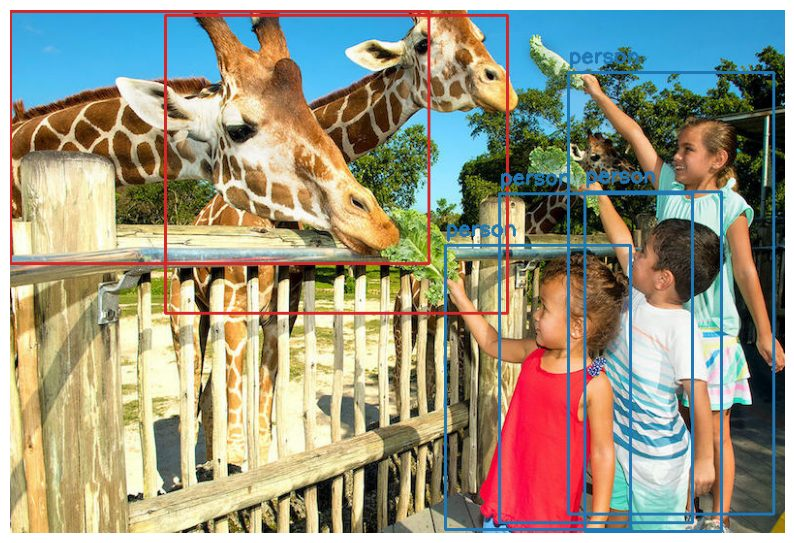

In [39]:
run_and_show(retinanet, image_example, 0.5, coco_class_to_label_map, verbose=True)

## Fine-tuning RetinaNet для детекции мячей

Модель дообучается на подмножестве Open Images с объектами класса `Ball`.


#### Загрузка данных

In [40]:
class DetectionDataset(torch.utils.data.Dataset):
    def __init__(self, data_dict_file, transforms=None, add_path=None):
        self.transforms = transforms

        with open(data_dict_file, 'r') as f:
            self.data_dict = json.load(f)
        if add_path:
            self.data_dict = {add_path + i:j for i,j in self.data_dict.items()}

        self.imgs = list(self.data_dict.keys())

    def __getitem__(self, idx):
        # load images ad masks
        img_path = self.imgs[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.
        h, w = image.shape[:2]
#         img = Image.open(img_path).convert("RGB")
#         w, h = img.size

        num_objs = len(self.data_dict[img_path])
        boxes = []
        for i in range(num_objs):
            bbox = self.data_dict[img_path][i]
            xmin = bbox[0] * w
            xmax = bbox[1] * w
            ymin = bbox[2] * h
            ymax = bbox[3] * h
            boxes.append([xmin, ymin, xmax, ymax])

        boxes = np.asarray(boxes)  # N x 4
        annot = np.zeros((len(boxes), 1))  # N x 1
        annot = np.concatenate((boxes, annot), axis=1)  # N x 5

        sample = {'img': image, 'annot': annot}

        if self.transforms:
            sample = self.transforms(sample)

        return sample

    def __len__(self):
        return len(self.imgs)

    def image_aspect_ratio(self, image_index):
        img_path = self.imgs[image_index]
        img = Image.open(img_path).convert("RGB") # slow
        w, h = img.size
        return w / h

    def num_classes(self):
        return 2

In [41]:
class Augmenter(object):
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample, flip_x=0.5):

        if np.random.rand() < flip_x:
            image, annots = sample['img'], sample['annot']
            image = image[:, ::-1, :]

            rows, cols, channels = image.shape

            x1 = annots[:, 0].copy()
            x2 = annots[:, 2].copy()

            x_tmp = x1.copy()

            annots[:, 0] = cols - x2
            annots[:, 2] = cols - x_tmp

            sample = {'img': image, 'annot': annots}

        return sample

In [42]:
class Normalizer(object):

    def __init__(self):
        self.mean = np.array([[[0.485, 0.456, 0.406]]])
        self.std = np.array([[[0.229, 0.224, 0.225]]])

    def __call__(self, sample):

        image, annots = sample['img'], sample['annot']

        return {'img':((image.astype(np.float32)-self.mean)/self.std), 'annot': annots}

In [43]:
class UnNormalizer(object):
    def __init__(self, mean=None, std=None):
        if mean == None:
            self.mean = [0.485, 0.456, 0.406]
        else:
            self.mean = mean
        if std == None:
            self.std = [0.229, 0.224, 0.225]
        else:
            self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be normalized.
        Returns:
            Tensor: Normalized image.
        """
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

In [44]:
class Resizer(object):
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample, min_side=608, max_side=1024):
        image, annots = sample['img'], sample['annot']

        rows, cols, cns = image.shape

        smallest_side = min(rows, cols)

        # rescale the image so the smallest side is min_side
        scale = min_side / smallest_side

        # check if the largest side is now greater than max_side, which can happen
        # when images have a large aspect ratio
        largest_side = max(rows, cols)

        if largest_side * scale > max_side:
            scale = max_side / largest_side

        # resize the image with the computed scale
        image = skimage.transform.resize(image, (int(round(rows*scale)), int(round((cols*scale)))))
        rows, cols, cns = image.shape

        pad_w = 32 - rows%32
        pad_h = 32 - cols%32

        new_image = np.zeros((rows + pad_w, cols + pad_h, cns)).astype(np.float32)
        new_image[:rows, :cols, :] = image.astype(np.float32)

        annots[:, :4] *= scale

        return {'img': torch.from_numpy(new_image), 'annot': torch.from_numpy(annots), 'scale': scale}

In [45]:
class RandomGrayscale(object):

    def __init__(self, p = 1):
        self.proba = p
        self.to_gray = transforms.RandomGrayscale(p=self.proba)

    def __call__(self, sample):

        image, annots = sample['img'], sample['annot']
        image = self.to_gray(image.permute(2,1,0))
        return {'img':image, 'annot': annots}

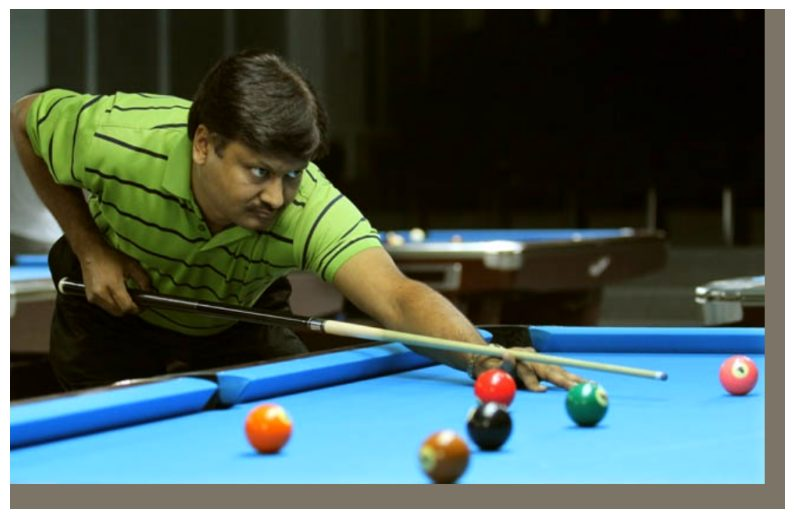

In [46]:
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.255],
    std=[1/0.229, 1/0.224, 1/0.255]
)

example_transforms = transforms.Compose([
    Normalizer(), Resizer()
])
example_dataset = DetectionDataset(data_dict_file="/content/dl-6-content/oi5_ball_filename_to_bbox_train.json",
                                 transforms=example_transforms, add_path = '/content/dl-6-content/')
iterator = iter(example_dataset)
exp_img = next(iterator)['img']
inv_tensor = inv_normalize(exp_img.permute(2,1,0))
show_image(inv_tensor.permute(2,1,0).numpy())

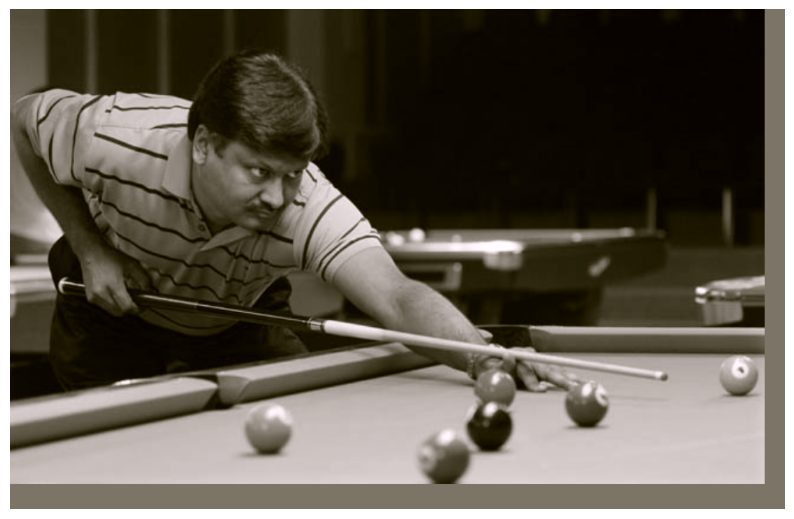

In [47]:
example_transforms = transforms.Compose([
    Normalizer(), Resizer(), RandomGrayscale()
])
example_dataset = DetectionDataset(data_dict_file="/content/dl-6-content/oi5_ball_filename_to_bbox_train.json",
                                 transforms=example_transforms, add_path = '/content/dl-6-content/')
iterator = iter(example_dataset)
exp_img = next(iterator)['img']
inv_tensor = inv_normalize(exp_img)
show_image(inv_tensor.permute(2,1,0).numpy())

In [48]:
train_transforms = transforms.Compose([
    Normalizer(), Augmenter(), Resizer()
])

val_transforms = transforms.Compose([
    Normalizer(), Resizer()
])

In [49]:
import random
from torch.utils.data import Sampler

In [50]:
class AspectRatioBasedSampler(Sampler):
    """Yes, because we'll be creating batches of these images, and since each image has varying sizes, we want to have
    mostly similar images in a batch so that they have to undergo minimal padding to make them the same size
    (we need the same size for all images in a batch because of how anchors are computed)"""
    def __init__(self, data_source, batch_size, drop_last):
        self.data_source = data_source
        self.batch_size = batch_size
        self.drop_last = drop_last
        self.groups = self.group_images()

    def __iter__(self):
        random.shuffle(self.groups)
        for group in self.groups:
            yield group

    def __len__(self):
        if self.drop_last:
            return len(self.data_source) // self.batch_size
        else:
            return (len(self.data_source) + self.batch_size - 1) // self.batch_size

    def group_images(self):
        # determine the order of the images
        order = list(range(len(self.data_source)))
        order.sort(key=lambda x: self.data_source.image_aspect_ratio(x))

        # divide into groups, one group = one batch
        return [[order[x % len(order)] for x in range(i, i + self.batch_size)] for i in range(0, len(order), self.batch_size)]

In [51]:
def collater(data):
    "Pad data"

    imgs = [s['img'] for s in data]
    annots = [s['annot'] for s in data]
    scales = [s['scale'] for s in data]

    widths = [int(s.shape[0]) for s in imgs]
    heights = [int(s.shape[1]) for s in imgs]
    batch_size = len(imgs)

    # defined max width and height
    max_width = np.array(widths).max()
    max_height = np.array(heights).max()

    # create maximum size image batch filled with zeros
    padded_imgs = torch.zeros(batch_size, max_width, max_height, 3)

    for i in range(batch_size):
        img = imgs[i]
        padded_imgs[i, :int(img.shape[0]), :int(img.shape[1]), :] = img # insert

    max_num_annots = max(annot.shape[0] for annot in annots)

    if max_num_annots > 0:
        # 5 stands for 4 points ([x1, y1, x2, y2]) and a classification class
        annot_padded = torch.ones((len(annots), max_num_annots, 5)) * -1

        if max_num_annots > 0:
            for idx, annot in enumerate(annots):
                #print(annot.shape)
                if annot.shape[0] > 0:
                    annot_padded[idx, :annot.shape[0], :] = annot
    else:
        annot_padded = torch.ones((len(annots), 1, 5)) * -1

    padded_imgs = padded_imgs.permute(0, 3, 1, 2)

    return {'img': padded_imgs, 'annot': annot_padded, 'scale': scales}

In [52]:
train_dataset = DetectionDataset(data_dict_file="/content/dl-6-content/oi5_ball_filename_to_bbox_train.json",
                                 transforms=train_transforms, add_path = '/content/dl-6-content/')
train_sampler = AspectRatioBasedSampler(train_dataset, batch_size=4, drop_last=False) # deepdive
train_dataloader = DataLoader(train_dataset, num_workers=8, collate_fn=collater, batch_sampler=train_sampler)

val_dataset = DetectionDataset(data_dict_file="/content/dl-6-content/oi5_ball_filename_to_bbox_val.json",
                               transforms=val_transforms, add_path = '/content/dl-6-content/')
val_sampler = AspectRatioBasedSampler(val_dataset, batch_size=4, drop_last=False)
val_dataloader = DataLoader(val_dataset, num_workers=8, collate_fn=collater, batch_sampler=val_sampler)

In [53]:
item = train_dataset[0]
print(item["img"].size())    # H x W x 3
print(item["annot"].size())  # N x 5; 4 coords + 1 label.

torch.Size([640, 992, 3])
torch.Size([6, 5])


#### Подготовка к обучению

In [54]:
retinanet.classification_head = ClassificationModel(num_features_in, num_classes=1)
retinanet.regression_head = RegressionModel(num_features_in)
retinanet.to(device)

RetinaNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
       

BatchNorm layers замораживаются во время fine-tuning, чтобы сохранить стабильные статистики предобученной модели при небольшом batch size.

In [55]:
def set_to_training(model, backbone=False, fpn=False, regression_head=True, classification_head=True, freeze_bn=False):
    model.train()
    model.requires_grad_(True)

    if not backbone:
        model.backbone.eval()
        model.backbone.requires_grad_(False)

    elif freeze_bn:
        for layer in model.backbone.modules():
            if isinstance(layer, nn.BatchNorm2d):
                layer.eval()

    if not fpn:
        model.fpn.eval()
        model.fpn.requires_grad_(False)

    if not regression_head:
        model.regression_head.eval()
        model.regression_head.requires_grad_(False)

    if not classification_head:
        model.classification_head.eval()
        model.classification_head.requires_grad_(False)

In [56]:
def val_step(model, dataloader):
    model.eval()
    metric_fn = MetricBuilder.build_evaluation_metric("map_2d", async_mode=False, num_classes=1)
    for iter_num, data in tqdm.tqdm(enumerate(dataloader), total=len(dataloader)):
      for img, gt in zip(data['img'], data['annot']):
        with torch.no_grad():
          nms_scores, nms_classes, bboxes = model(img.unsqueeze(0))
        preds = torch.cat([bboxes, nms_classes.unsqueeze(0).T, nms_scores.unsqueeze(0).T], dim = 1).cpu().detach().numpy()
        zeros = torch.zeros((gt.shape[0], 1))
        gt = torch.cat([gt, zeros, zeros], 1).cpu().detach().numpy()
        metric_fn.add(preds, gt)

        del img, gt, preds, zeros, nms_scores, nms_classes, bboxes
      gc.collect()
      torch.cuda.empty_cache()
    print(f"validation mAP in all points: {metric_fn.value(iou_thresholds=0.5)['mAP']}")


def routine(retina_model, scheduler, train_loader, val_loader):
    epoch_loss = []
    torch.cuda.empty_cache()
    for iter_num, data in tqdm.tqdm(enumerate(train_dataloader), total=len(train_dataloader)):

        optimizer.zero_grad()

        classification_loss, regression_loss = retina_model([data['img'].to(device).float(), data['annot'].to(device)])
        classification_loss = classification_loss.mean()
        regression_loss = regression_loss.mean()

        loss = classification_loss + regression_loss

        if bool(loss == 0):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(retina_model.parameters(), 0.1)
        optimizer.step()

        epoch_loss.append(float(loss.item()))
        del data

    gc.collect()
    torch.cuda.empty_cache()

    print('Epoch: {} | Iteration: {} | Train classification loss: {:1.5f} | train regression loss: {:1.5f} | Epoch loss: {:1.5f}'\
          .format(epoch_num, iter_num, float(classification_loss), float(regression_loss), np.mean(epoch_loss)))
    scheduler.step(np.mean(epoch_loss)) # should be val loss

#### Обучение

Сначала обучим только новые головы в течение 1 эпохи:

In [57]:
set_to_training(retinanet, backbone=False, fpn=False, regression_head=True, classification_head=True, freeze_bn=True)

In [58]:
params = [p for p in retinanet.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

In [59]:
epochs = 1
for epoch_num in range(epochs):
    routine(retinanet, scheduler, train_dataloader, val_dataloader)

100%|██████████| 719/719 [08:56<00:00,  1.34it/s]


Epoch: 0 | Iteration: 718 | Train classification loss: 0.11634 | train regression loss: 0.27753 | Epoch loss: 4.23519


In [60]:
val_step(retinanet, val_dataloader)

100%|██████████| 57/57 [00:59<00:00,  1.05s/it]

validation mAP in all points: 0.5530245304107666


И потом обучим всю сеть (с "замороженными" BN) - уже подольше.

In [61]:
set_to_training(retinanet, backbone=True, fpn=True, regression_head=True, classification_head=True, freeze_bn=False)

In [62]:
params = [p for p in retinanet.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

In [63]:
epochs = 10
for epoch_num in range(epochs):
    routine(retinanet, scheduler, train_dataloader, val_dataloader)

    if epoch_num % 10 == 0 or epoch_num + 1 == epochs:
        torch.save(retinanet.state_dict(), f"dev_balls_retinanet_{epoch_num}.pt")

100%|██████████| 719/719 [10:22<00:00,  1.16it/s]


Epoch: 0 | Iteration: 718 | Train classification loss: 0.27244 | train regression loss: 0.28201 | Epoch loss: 0.99843


100%|██████████| 719/719 [10:24<00:00,  1.15it/s]


Epoch: 1 | Iteration: 718 | Train classification loss: 0.38738 | train regression loss: 0.28792 | Epoch loss: 0.70046


100%|██████████| 719/719 [10:24<00:00,  1.15it/s]


Epoch: 2 | Iteration: 718 | Train classification loss: 0.13286 | train regression loss: 0.29658 | Epoch loss: 0.60488


100%|██████████| 719/719 [10:26<00:00,  1.15it/s]


Epoch: 3 | Iteration: 718 | Train classification loss: 0.04407 | train regression loss: 0.18963 | Epoch loss: 0.54837


 36%|███▌      | 257/719 [03:52<06:57,  1.11it/s]


KeyboardInterrupt: 

In [64]:
val_step(retinanet, val_dataloader)

100%|██████████| 57/57 [00:58<00:00,  1.02s/it]

validation mAP in all points: 0.3795156180858612


#### Оценка качества

In [65]:
with open("/content/dl-6-content/oi5_ball_retinanet_ep=10.pt", "rb") as fp:
    state_dict = torch.load(fp, map_location="cpu")
retinanet.load_state_dict(state_dict)

<All keys matched successfully>

In [66]:
retinanet.eval();

In [67]:
val_step(retinanet, val_dataloader)

100%|██████████| 57/57 [00:59<00:00,  1.04s/it]

validation mAP in all points: 0.41292092204093933


torch.Size([0]) tensor([])
torch.Size([0]) tensor([])
torch.Size([0, 4]) tensor([], size=(0, 4))


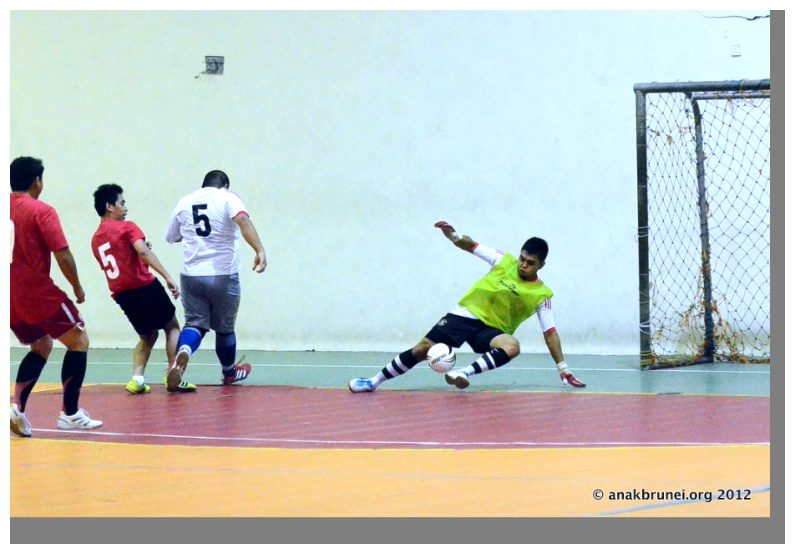

torch.Size([1]) tensor([0.8864])
torch.Size([1]) tensor([0])
torch.Size([1, 4]) tensor([[  0.0000,  17.1084, 902.3615, 616.6019]])


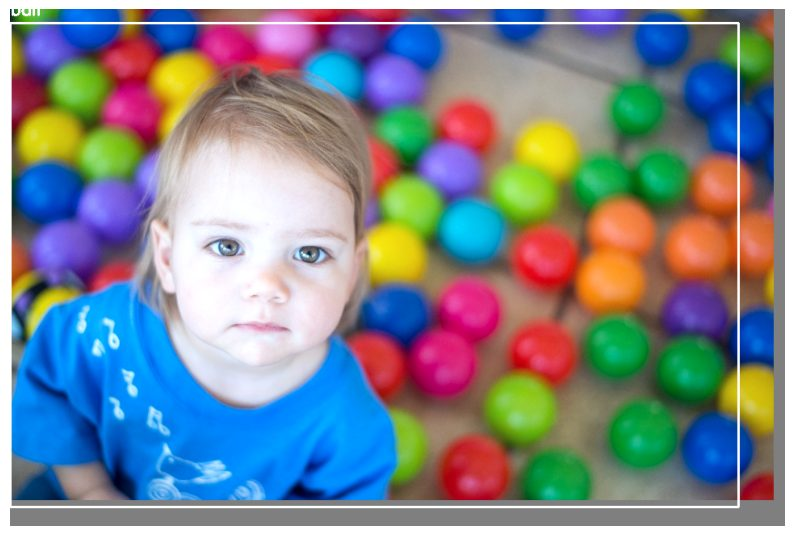

torch.Size([2]) tensor([0.8645, 0.3169])
torch.Size([2]) tensor([0, 0])
torch.Size([2, 4]) tensor([[  0.0000,   0.0000, 584.4890, 910.2000],
        [280.9787, 350.2948, 415.1867, 484.1052]])


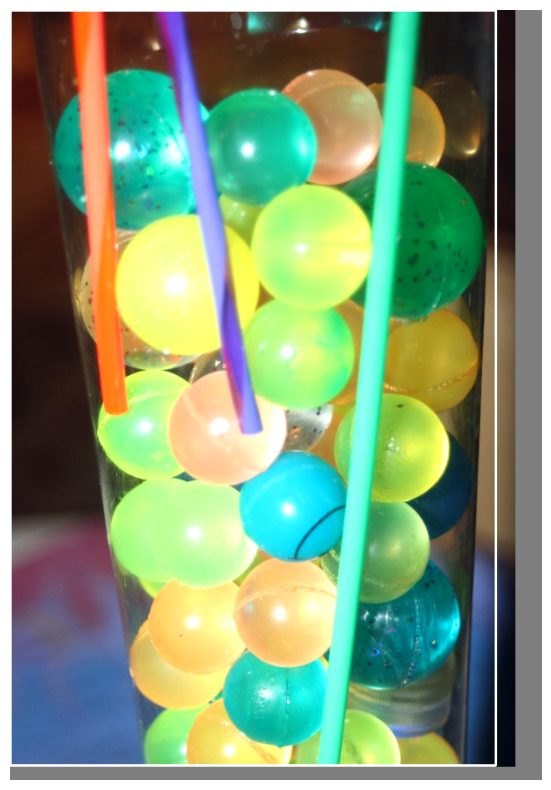

torch.Size([2]) tensor([0.8779, 0.3088])
torch.Size([2]) tensor([0, 0])
torch.Size([2, 4]) tensor([[ 39.3252,  21.4186, 833.7728, 604.6710],
        [461.1386,  18.3444, 846.9630, 409.0430]])


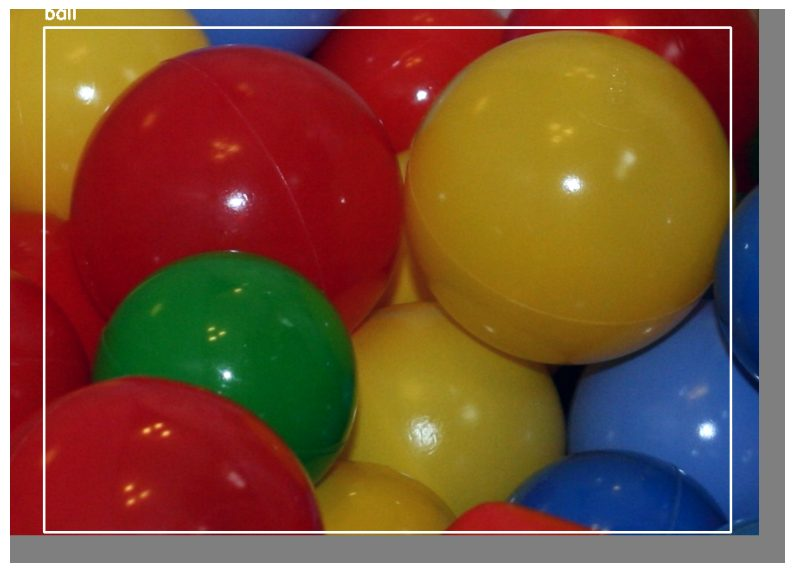

torch.Size([1]) tensor([0.9225])
torch.Size([1]) tensor([0])
torch.Size([1, 4]) tensor([[136.1954, 463.6064, 218.9338, 540.3979]])


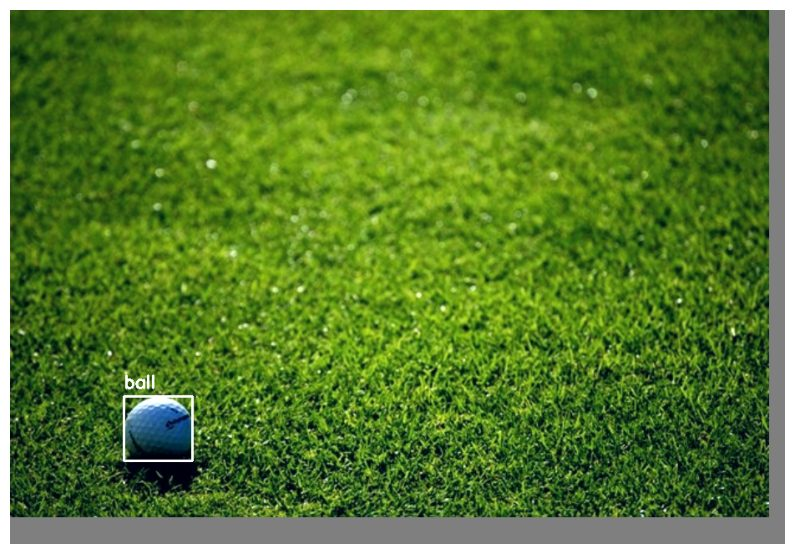

torch.Size([1]) tensor([0.8113])
torch.Size([1]) tensor([0])
torch.Size([1, 4]) tensor([[271.3383, 123.9757, 348.2026, 203.7619]])


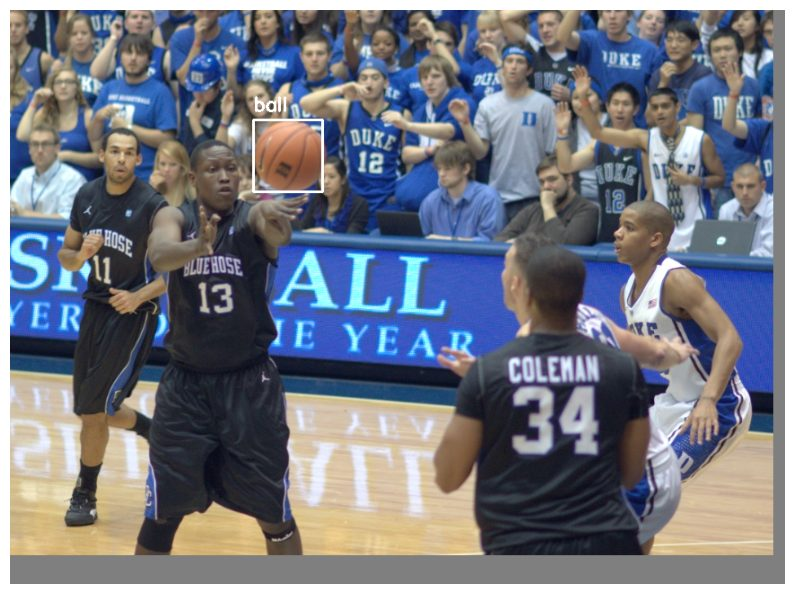

torch.Size([1]) tensor([0.5624])
torch.Size([1]) tensor([0])
torch.Size([1, 4]) tensor([[224.1411,  69.3635, 315.8539, 172.1224]])


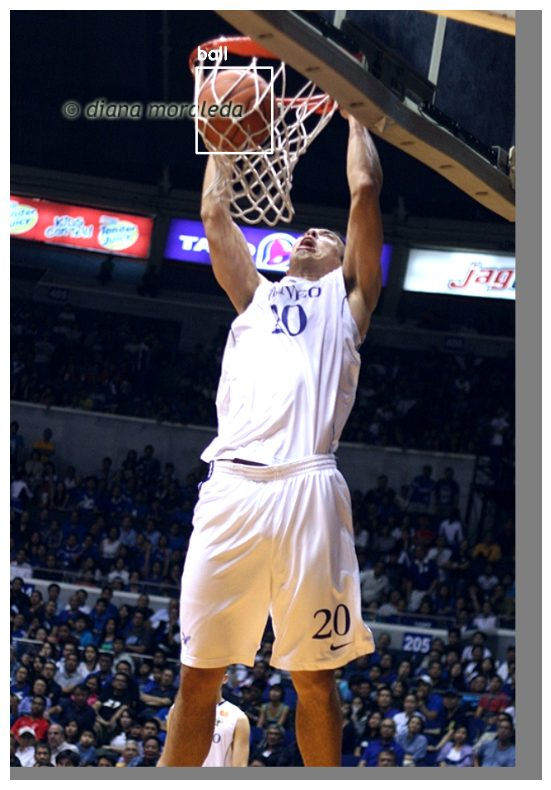

torch.Size([1]) tensor([0.8151])
torch.Size([1]) tensor([0])
torch.Size([1, 4]) tensor([[406.5494, 354.4407, 443.0013, 391.7738]])


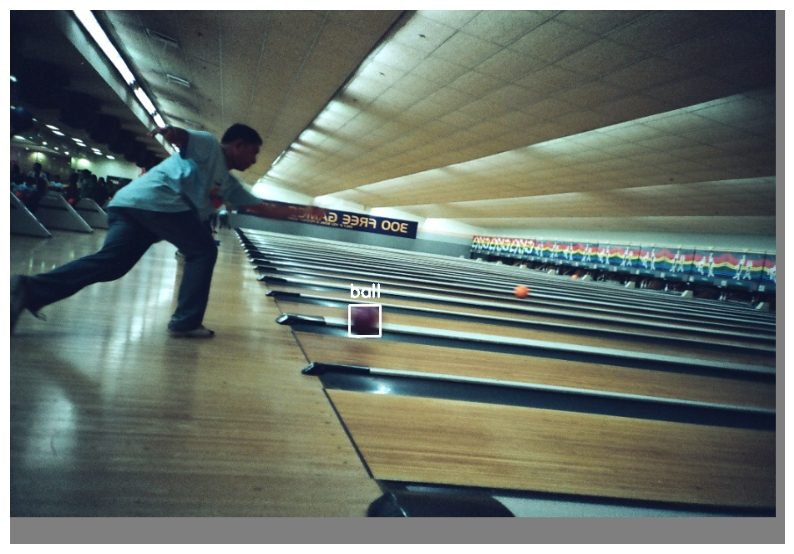

torch.Size([1]) tensor([0.7491])
torch.Size([1]) tensor([0])
torch.Size([1, 4]) tensor([[264.6035,   0.3904, 335.3458, 104.1587]])


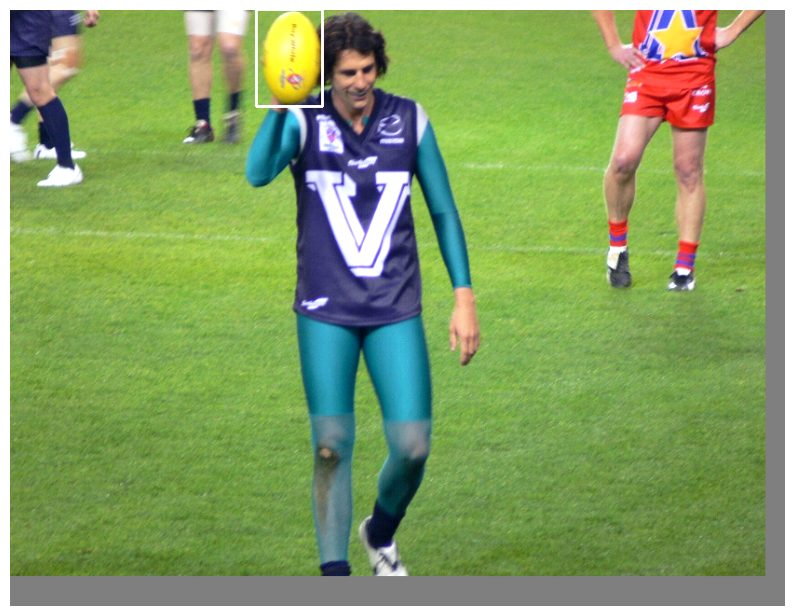

torch.Size([1]) tensor([0.7008])
torch.Size([1]) tensor([0])
torch.Size([1, 4]) tensor([[858.2169, 404.0818, 881.9504, 428.5293]])


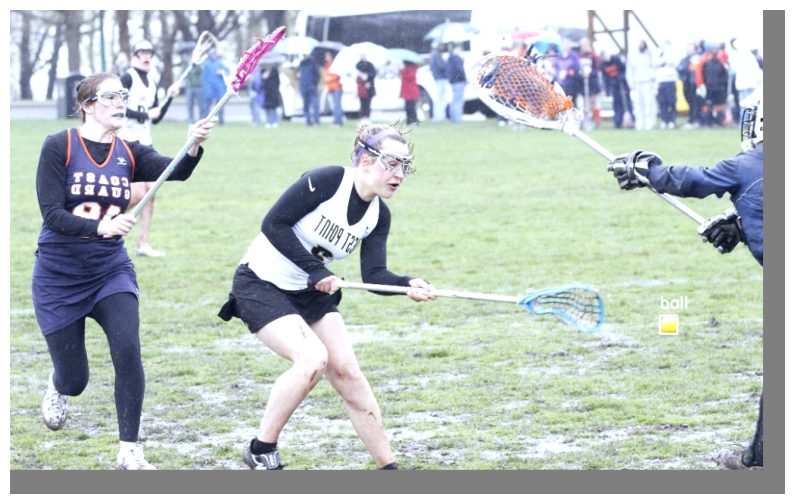

In [68]:
for i in range(10):
    index = np.random.randint(len(train_dataset))
    tensor = train_dataset[index]["img"].unsqueeze(0)
    run_and_show(retinanet, tensor, 0.5, {0: "ball"}, verbose=True)

Пример из валидации:

torch.Size([1]) tensor([0.7633])
torch.Size([1]) tensor([0])
torch.Size([1, 4]) tensor([[  4.3455,  78.7026, 407.9878, 510.4055]])


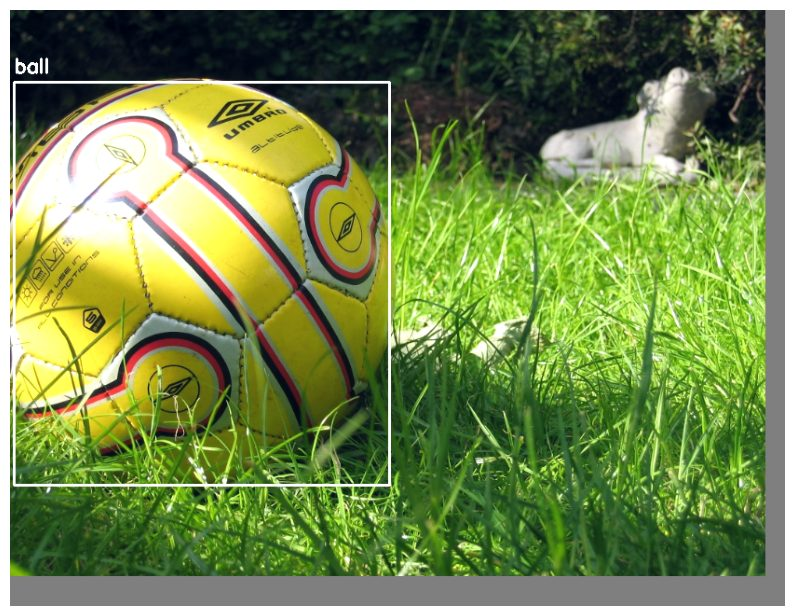

torch.Size([1]) tensor([0.3477])
torch.Size([1]) tensor([0])
torch.Size([1, 4]) tensor([[674.9385, 575.8317, 723.6529, 608.1917]])


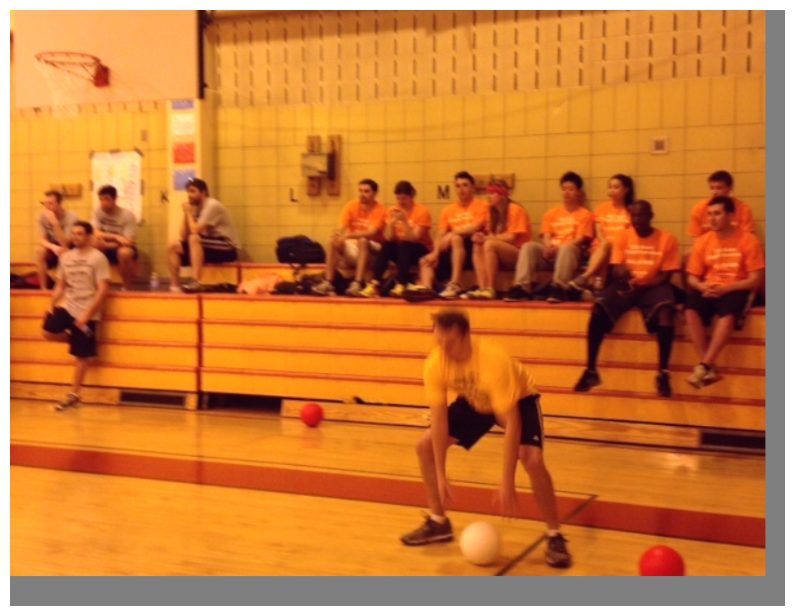

torch.Size([0]) tensor([])
torch.Size([0]) tensor([])
torch.Size([0, 4]) tensor([], size=(0, 4))


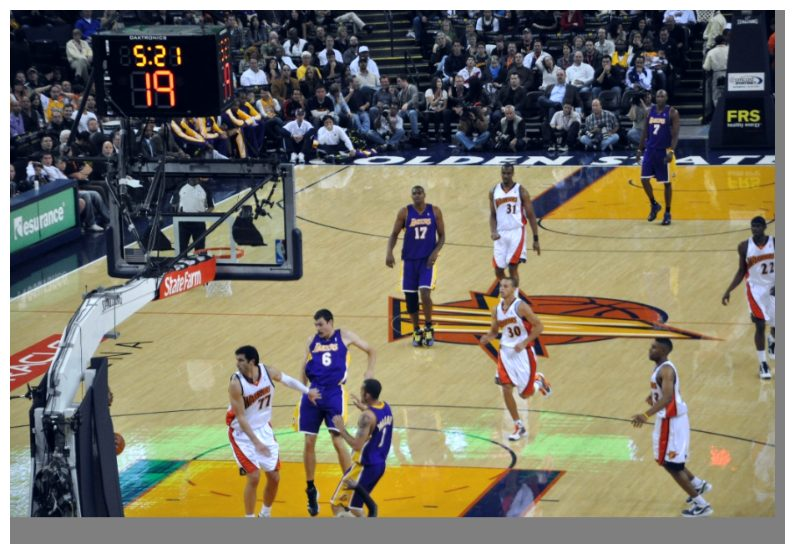

torch.Size([0]) tensor([])
torch.Size([0]) tensor([])
torch.Size([0, 4]) tensor([], size=(0, 4))


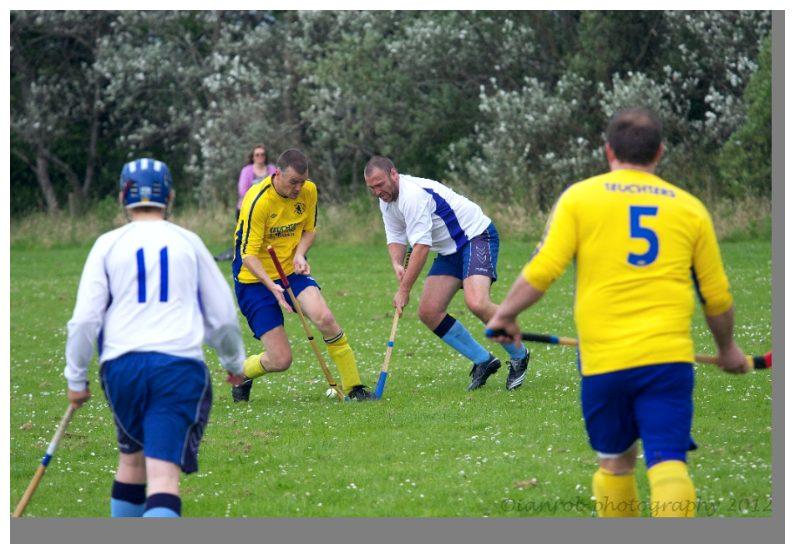

torch.Size([2]) tensor([0.9410, 0.5340])
torch.Size([2]) tensor([0, 0])
torch.Size([2, 4]) tensor([[679.5385, 244.9219, 719.6588, 287.9084],
        [453.5014, 266.4030, 492.2945, 306.0163]])


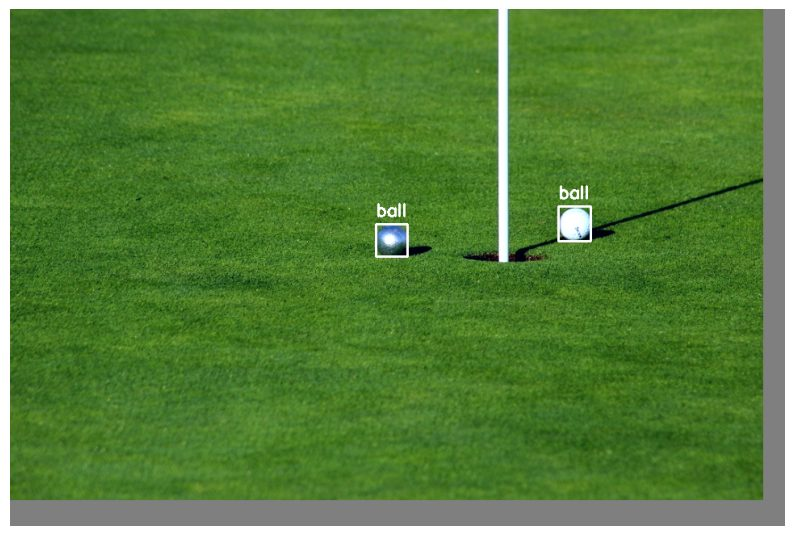

torch.Size([0]) tensor([])
torch.Size([0]) tensor([])
torch.Size([0, 4]) tensor([], size=(0, 4))


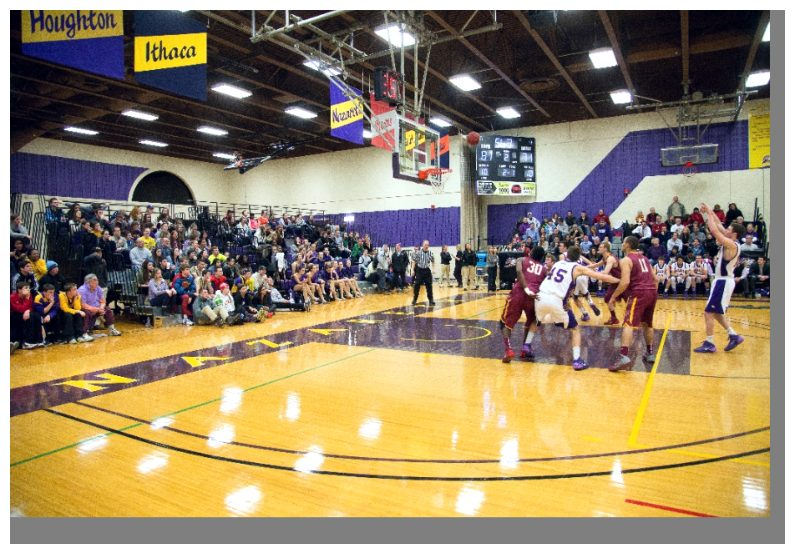

torch.Size([0]) tensor([])
torch.Size([0]) tensor([])
torch.Size([0, 4]) tensor([], size=(0, 4))


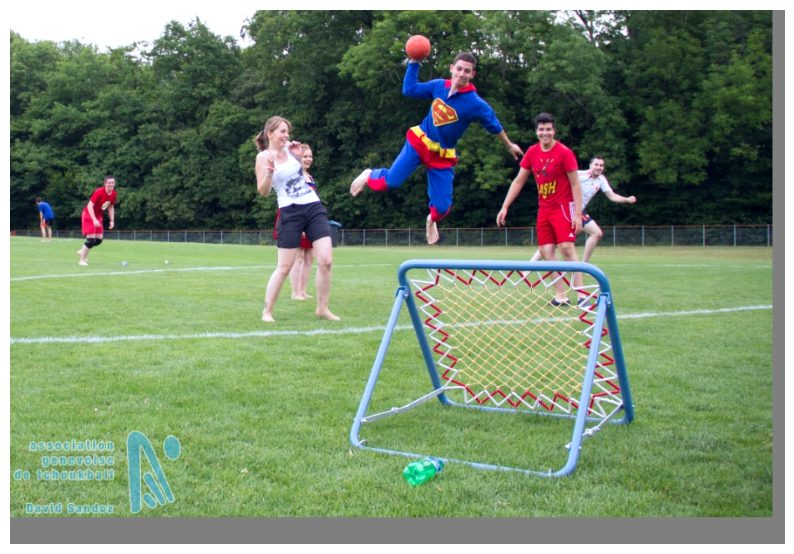

torch.Size([2]) tensor([0.4059, 0.3278])
torch.Size([2]) tensor([0, 0])
torch.Size([2, 4]) tensor([[ 40.1806, 295.4111, 626.9911, 458.6201],
        [313.3907, 294.5301, 615.2976, 454.0197]])


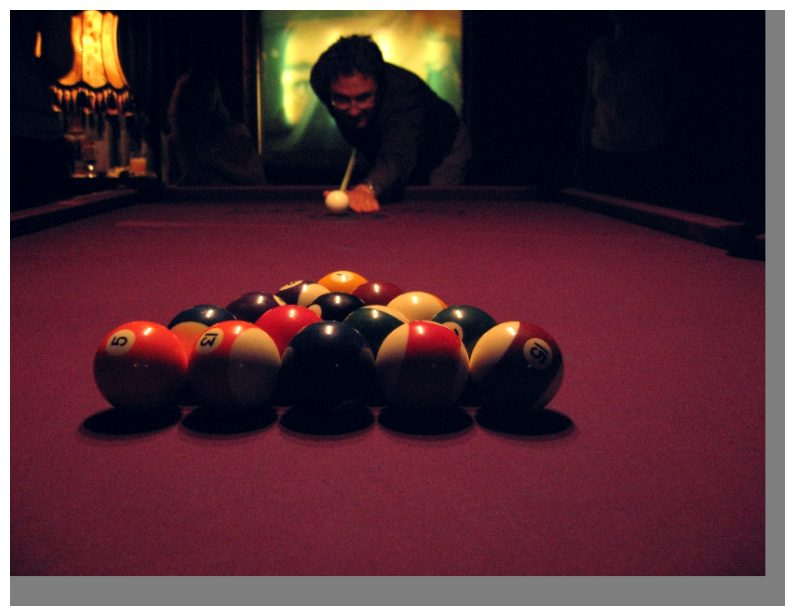

torch.Size([1]) tensor([0.4146])
torch.Size([1]) tensor([0])
torch.Size([1, 4]) tensor([[  5.6230,   0.0000, 520.9406, 414.6458]])


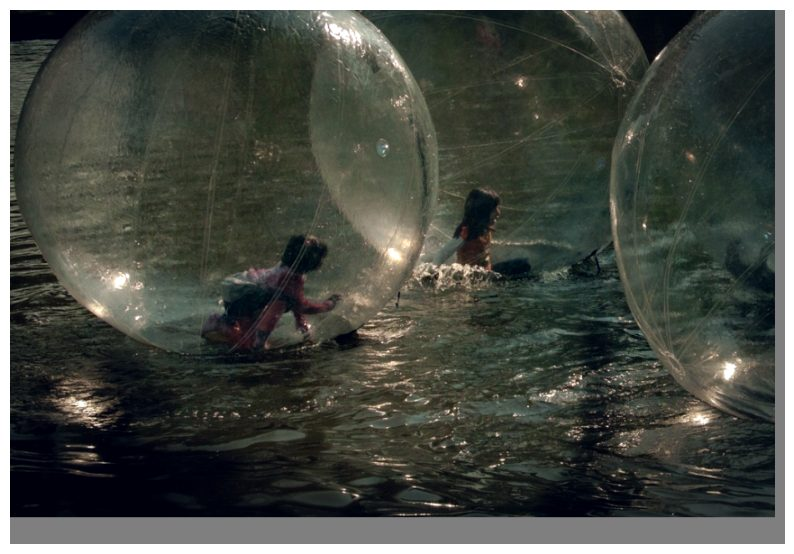

torch.Size([0]) tensor([])
torch.Size([0]) tensor([])
torch.Size([0, 4]) tensor([], size=(0, 4))


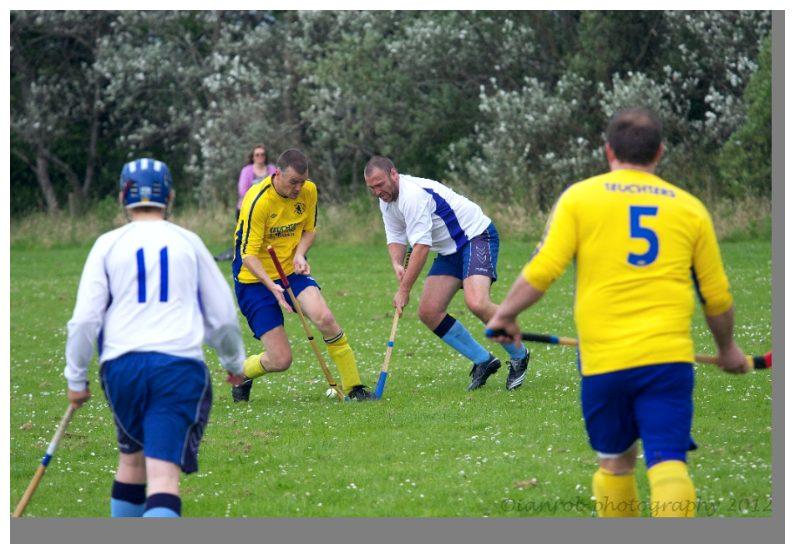

In [69]:
for i in range(10):
    index = np.random.randint(len(val_dataset))
    tensor = val_dataset[index]["img"].unsqueeze(0)
    run_and_show(retinanet, tensor, 0.5, {0: "ball"}, verbose=True)

---

### Решение: DETR (DEtection TRansformer) Hugging Face

[link](https://huggingface.co/learn/computer-vision-course/unit3/vision-transformers/detr?)

- **Transformer** берет набор векторов, через self-attention каждый токен “смотрит” на все остальные, взвешивает важные связи и обновляет свое представление; затем MLP это дообрабатывает, и так в несколько слоев.
- В DETR это применяют к признакам изображения и object queries, чтобы получить объекты и их боксы.
- **Self-attention** — это механизм, где каждый элемент входа (токен/патч) сравнивается со всеми остальными, получает веса важности и обновляется как взвешенная сумма их признаков
- DETR из Hugging Face: `Image -> ResNet-50 backbone -> 2D feature map + positional encoding -> Transformer encoder -> Transformer decoder (object queries) -> (class head + box head) -> N object predictions (class + bbox, включая no-object)`
- Получается, у нас один целевой класс: ball, фон -> noobj реализован отдельно в модели DETR

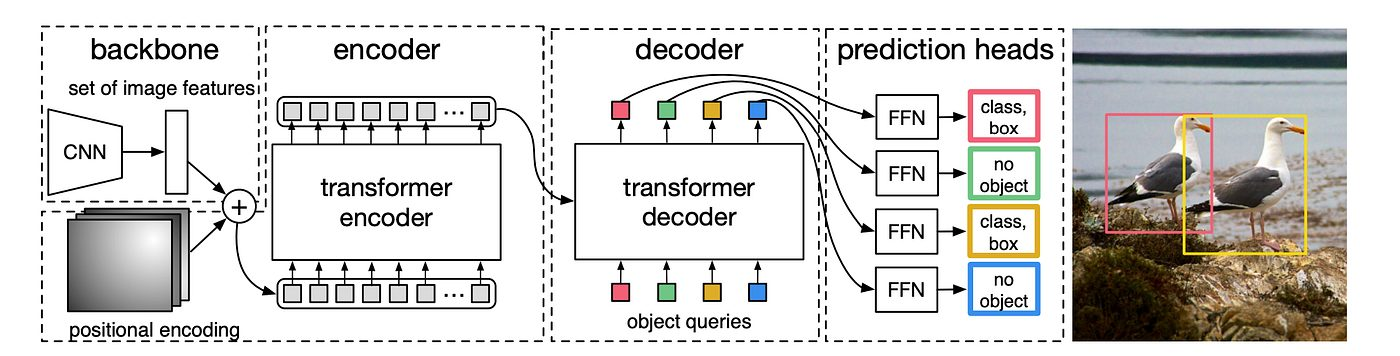

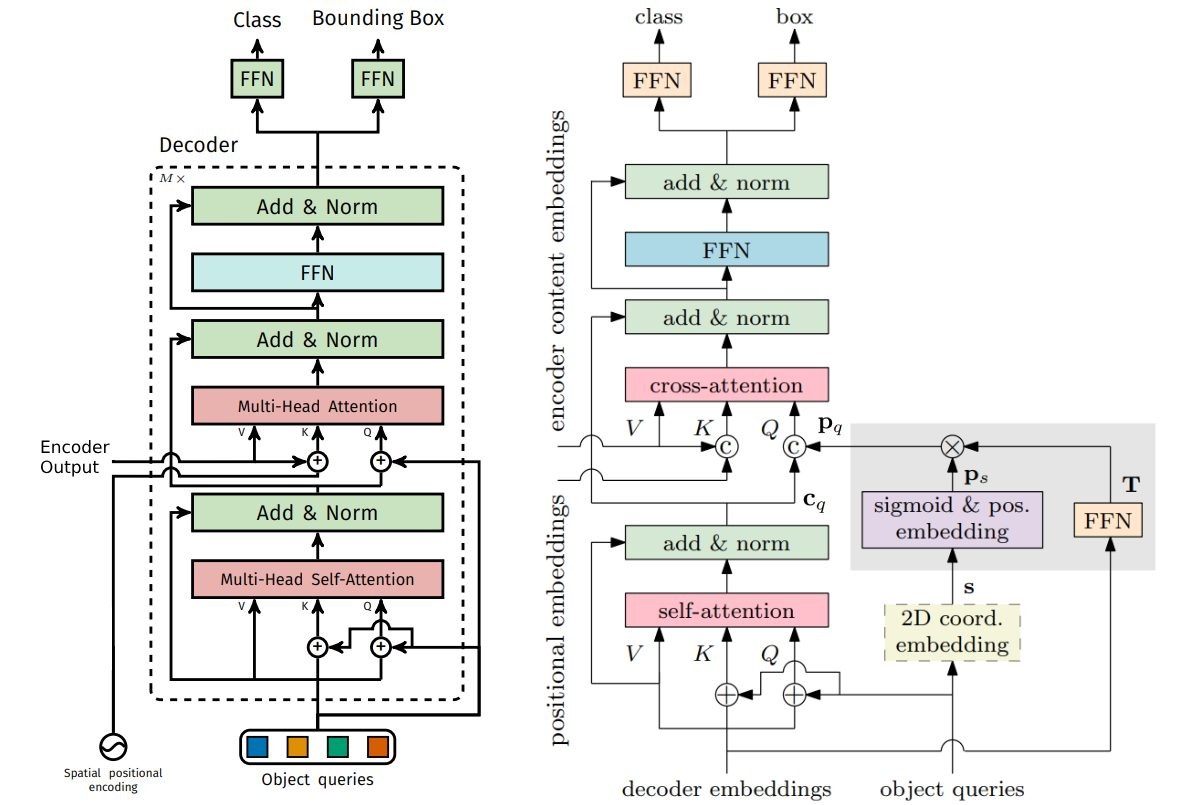

In [5]:
!pip -q install transformers

from transformers import AutoImageProcessor, AutoModelForObjectDetection

ckpt = "facebook/detr-resnet-50"
image_processor = AutoImageProcessor.from_pretrained(ckpt, use_fast=False)

hf_model = AutoModelForObjectDetection.from_pretrained(
    ckpt,
    num_labels=1,
    id2label={0: "ball"},
    label2id={"ball": 0},
    ignore_mismatched_sizes=True
).to(device)


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |                                                                                      
----------------------------------------------------------------------------+------------+--------------------------------------------------------------------------------------
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer4.0.downsam

In [6]:
from transformers import AutoImageProcessor

hf_checkpoint = "facebook/detr-resnet-50"
image_processor = AutoImageProcessor.from_pretrained(hf_checkpoint, use_fast=False)


In [7]:
class BallHFDetDataset(torch.utils.data.Dataset):
    def __init__(self, data_dict_file, images_root="/content/dl-6-content/", processor=None, train=False):
        with open(data_dict_file) as f:
            self.data = json.load(f)
        self.keys = list(self.data.keys())
        self.root, self.processor, self.train = images_root, processor, train

    def __len__(self):
        return len(self.keys)

    def _path(self, k):
        return k if os.path.isabs(k) else os.path.join(self.root, k)

    def __getitem__(self, idx):
        k = self.keys[idx]
        img = cv2.cvtColor(cv2.imread(self._path(k)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        boxes = [[b[0]*w, b[2]*h, b[1]*w, b[3]*h] for b in self.data[k]]  # xyxy

        if self.train and np.random.rand() < 0.5:
            img = img[:, ::-1, :].copy()
            boxes = [[w-x2, y1, w-x1, y2] for x1, y1, x2, y2 in boxes]

        anns = [{
            "image_id": idx, "category_id": 0,
            "bbox": [x1, y1, max(x2-x1, 1.0), max(y2-y1, 1.0)],
            "area": max(x2-x1, 1.0) * max(y2-y1, 1.0),
            "iscrowd": 0
        } for x1, y1, x2, y2 in boxes]

        enc = self.processor(
            images=img,
            annotations={"image_id": idx, "annotations": anns},
            return_tensors="pt"
        )

        gt_boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
        gt_labels = torch.zeros((gt_boxes.shape[0],), dtype=torch.int64)
        orig_size = torch.tensor([h, w], dtype=torch.int64)

        return enc["pixel_values"].squeeze(0), enc["labels"][0], gt_boxes, gt_labels, orig_size


def hf_collate_fn(batch):
    pixel_values, labels, gt_boxes, gt_labels, orig_sizes = zip(*batch)
    padded = image_processor.pad(list(pixel_values), return_tensors="pt")  # <- image_processor

    return {
        "pixel_values": padded["pixel_values"],
        "pixel_mask": padded["pixel_mask"],
        "labels": list(labels),
        "gt_boxes": list(gt_boxes),
        "gt_labels": list(gt_labels),
        "orig_sizes": torch.stack(list(orig_sizes)),
    }


In [8]:
root = "/content/dl-6-content/"

train_dataset_hf = BallHFDetDataset(f"{root}oi5_ball_filename_to_bbox_train.json", root, image_processor, True)
val_dataset_hf   = BallHFDetDataset(f"{root}oi5_ball_filename_to_bbox_val.json",   root, image_processor, False)

loader_kwargs = dict(batch_size=2, num_workers=0, collate_fn=hf_collate_fn)
train_loader_hf = DataLoader(train_dataset_hf, shuffle=True,  **loader_kwargs)
val_loader_hf   = DataLoader(val_dataset_hf,   shuffle=False, **loader_kwargs)

print(f"Train size: {len(train_dataset_hf)} | Val size: {len(val_dataset_hf)}")


Train size: 2875 | Val size: 226


In [10]:
# train + val(mAP@0.5)

def train_epoch(model, loader, optimizer, device):
    model.train()
    total = 0.0
    for b in tqdm.tqdm(loader):
        out = model(
            pixel_values=b["pixel_values"].to(device),
            pixel_mask=b["pixel_mask"].to(device),
            labels=[{k: v.to(device) for k, v in t.items()} for t in b["labels"]],
        )
        optimizer.zero_grad()
        out.loss.backward()
        optimizer.step()
        total += out.loss.item()
    return total / max(len(loader), 1)


def _pred_to_map(pred):
    boxes = pred["boxes"].cpu().numpy()
    if len(boxes) == 0:
        return np.zeros((0, 6), dtype=np.float32)
    scores = pred["scores"].cpu().numpy().reshape(-1, 1)
    labels = pred["labels"].cpu().numpy().reshape(-1, 1)
    return np.concatenate([boxes, labels, scores], axis=1).astype(np.float32)


def _gt_to_map(boxes_t, labels_t):
    boxes = boxes_t.numpy()
    if len(boxes) == 0:
        return np.zeros((0, 7), dtype=np.float32)
    labels = labels_t.numpy().reshape(-1, 1)
    difficult = np.zeros((len(boxes), 1), dtype=np.float32)
    crowd = np.zeros((len(boxes), 1), dtype=np.float32)
    return np.concatenate([boxes, labels, difficult, crowd], axis=1).astype(np.float32)


def eval_map(model, loader, processor, device):
    model.eval()
    metric = MetricBuilder.build_evaluation_metric("map_2d", async_mode=False, num_classes=1)

    with torch.no_grad():
        for b in tqdm.tqdm(loader):
            out = model(
                pixel_values=b["pixel_values"].to(device),
                pixel_mask=b["pixel_mask"].to(device),
            )
            preds = processor.post_process_object_detection(
                out, threshold=0.05, target_sizes=b["orig_sizes"]
            )
            for p, gt_b, gt_l in zip(preds, b["gt_boxes"], b["gt_labels"]):
                metric.add(_pred_to_map(p), _gt_to_map(gt_b, gt_l))

    return metric.value(iou_thresholds=0.5)["mAP"]


optimizer_hf = torch.optim.AdamW((p for p in hf_model.parameters() if p.requires_grad), lr=1e-5)
epochs_hf = 5

for e in range(epochs_hf):
    tr_loss = train_epoch(hf_model, train_loader_hf, optimizer_hf, device)
    val_map = eval_map(hf_model, val_loader_hf, image_processor, device)
    print(f"Epoch {e+1}/{epochs_hf} | train_loss={tr_loss:.4f} | val_mAP@0.5={val_map:.4f}")

torch.save(hf_model.state_dict(), "hf_detr_ball.pt")
print("Saved model to hf_detr_ball.pt")


100%|██████████| 113/113 [00:37<00:00,  3.04it/s]


Epoch 1/5 | train_loss=1.0922 | val_mAP@0.5=0.1812


100%|██████████| 113/113 [00:36<00:00,  3.06it/s]


Epoch 2/5 | train_loss=1.1018 | val_mAP@0.5=0.1491


100%|██████████| 113/113 [00:36<00:00,  3.09it/s]


Epoch 3/5 | train_loss=1.0497 | val_mAP@0.5=0.3404


100%|██████████| 113/113 [00:36<00:00,  3.09it/s]


Epoch 4/5 | train_loss=0.8905 | val_mAP@0.5=0.4234


100%|██████████| 113/113 [00:36<00:00,  3.08it/s]


Epoch 5/5 | train_loss=0.9827 | val_mAP@0.5=0.4336
Saved model to hf_detr_ball.pt


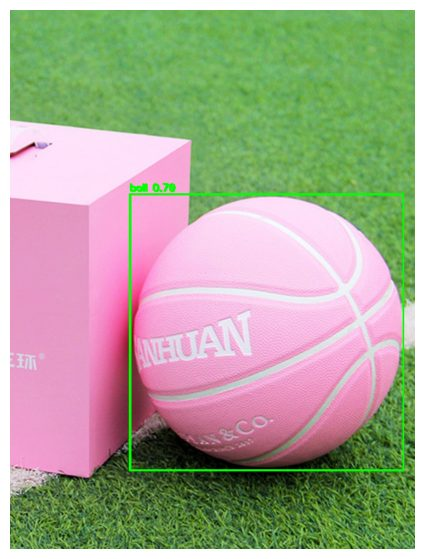

In [11]:
img = cv2.cvtColor(cv2.imread("/content/orig.jpg"), cv2.COLOR_BGR2RGB)
inputs = {k: v.to(device) for k, v in image_processor(images=img, return_tensors="pt").items()}
with torch.no_grad(): out = hf_model(**inputs)
pred = image_processor.post_process_object_detection(out, threshold=0.5, target_sizes=torch.tensor([img.shape[:2]]))[0]

vis = img.copy()
for b, s in zip(pred["boxes"].cpu().numpy(), pred["scores"].cpu().numpy()):
    x1, y1, x2, y2 = b.astype(int)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(vis, f"ball {s:.2f}", (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.figure(figsize=(10, 7))
plt.imshow(vis)
plt.axis("off")
plt.show()

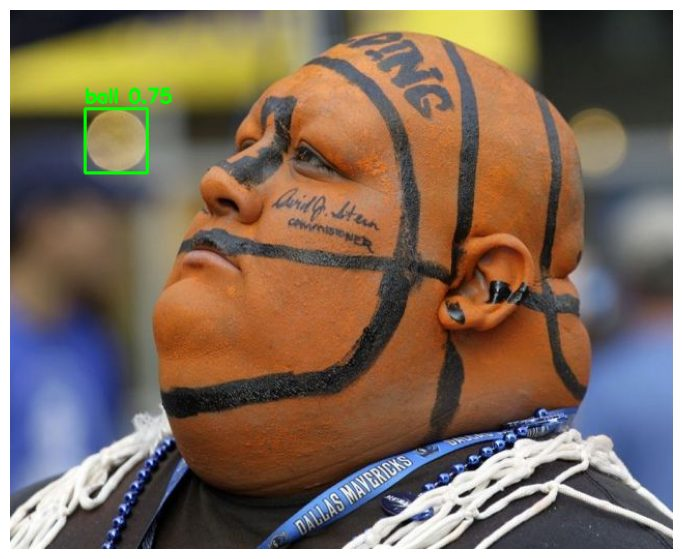

In [13]:
img = cv2.cvtColor(cv2.imread("/content/manball.jpeg"), cv2.COLOR_BGR2RGB)
inputs = {k: v.to(device) for k, v in image_processor(images=img, return_tensors="pt").items()}
with torch.no_grad(): out = hf_model(**inputs)
pred = image_processor.post_process_object_detection(out, threshold=0.5, target_sizes=torch.tensor([img.shape[:2]]))[0]

vis = img.copy()
for b, s in zip(pred["boxes"].cpu().numpy(), pred["scores"].cpu().numpy()):
    x1, y1, x2, y2 = b.astype(int)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(vis, f"ball {s:.2f}", (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.figure(figsize=(10, 7))
plt.imshow(vis)
plt.axis("off")
plt.show()

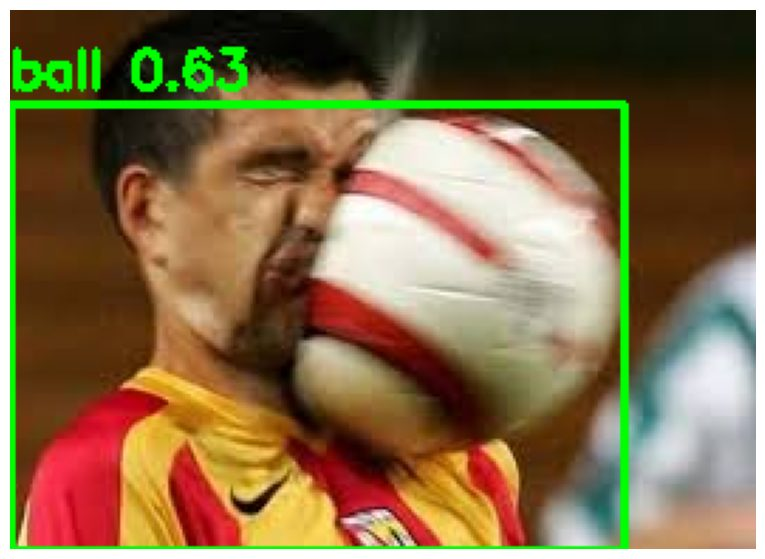

In [12]:
img = cv2.cvtColor(cv2.imread("/content/moving_ball.jpeg"), cv2.COLOR_BGR2RGB)
inputs = {k: v.to(device) for k, v in image_processor(images=img, return_tensors="pt").items()}
with torch.no_grad(): out = hf_model(**inputs)
pred = image_processor.post_process_object_detection(out, threshold=0.5, target_sizes=torch.tensor([img.shape[:2]]))[0]

vis = img.copy()
for b, s in zip(pred["boxes"].cpu().numpy(), pred["scores"].cpu().numpy()):
    x1, y1, x2, y2 = b.astype(int)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(vis, f"ball {s:.2f}", (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.figure(figsize=(10, 7))
plt.imshow(vis)
plt.axis("off")
plt.show()

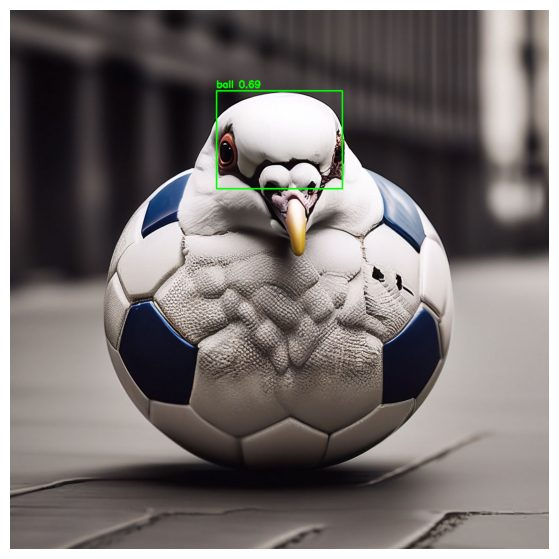

In [14]:
img = cv2.cvtColor(cv2.imread("/content/hunger.jpeg"), cv2.COLOR_BGR2RGB)
inputs = {k: v.to(device) for k, v in image_processor(images=img, return_tensors="pt").items()}
with torch.no_grad(): out = hf_model(**inputs)
pred = image_processor.post_process_object_detection(out, threshold=0.5, target_sizes=torch.tensor([img.shape[:2]]))[0]

vis = img.copy()
for b, s in zip(pred["boxes"].cpu().numpy(), pred["scores"].cpu().numpy()):
    x1, y1, x2, y2 = b.astype(int)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(vis, f"ball {s:.2f}", (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.figure(figsize=(10, 7))
plt.imshow(vis)
plt.axis("off")
plt.show()

почти :)